Gaze analysis


In [ ]:
import pandas as pd
import numpy as np
import yaml
import os

In [ ]:


# === ✅ CONFIGURATION
participant_id = "P09"
base_dir = "/content"
fps = 24.95

# === ✅ PATHS
csv_file = os.path.join(base_dir, f"{participant_id}_gaze_synced_real_with_class.csv")
yaml_file = os.path.join(base_dir, "segments_P01.yaml")
output_file = os.path.join(base_dir, f"{participant_id}_gaze_with_segment.csv")

# === ✅ Load gaze data
df = pd.read_csv(csv_file)
print(f"✅ Loaded: {len(df)} fixations")

# === ✅ Load YAML with segments
with open(yaml_file, "r") as f:
    config = yaml.safe_load(f)

segments = config["segments"]

# === ✅ Convert HH:MM:SS to frame index
def time_to_frame(time_str):
    h, m, s = map(int, time_str.split(":"))
    total_seconds = h * 3600 + m * 60 + s
    return int(total_seconds * fps)

# === ✅ Assign segment_id to each fixation
df['segment_id'] = -1

for segment in segments:
    segment_id = segment['segment_id']
    start_frame = time_to_frame(segment['start_time'])
    end_frame = time_to_frame(segment['end_time'])

    df.loc[(df['frame_idx'] >= start_frame) & (df['frame_idx'] < end_frame), 'segment_id'] = segment_id

print("✅ Assigned segment IDs")

# === ✅ Save new file
df.to_csv(output_file, index=False)
print(f"🏁✅ Done. Saved to {output_file}")

✅ Loaded: 27380 fixations
✅ Assigned segment IDs
🏁✅ Done. Saved to /content/P09_gaze_with_segment.csv


In [ ]:
# === ✅ CONFIGURATION ===
participant_id = "P01"
base_dir = "/content"
input_csv = os.path.join(base_dir, f"{participant_id}_gaze_with_segment.csv")
output_dir = os.path.join(base_dir, f"{participant_id}_objective_analysis")
os.makedirs(output_dir, exist_ok=True)

# ✅ Class labels mapping
class_labels = {
    0: "Bird", 1: "Ground Animal", 2: "Curb", 3: "Fence", 4: "Guard Rail", 5: "Barrier", 6: "Wall",
    7: "Bike Lane", 8: "Crosswalk - Plain", 9: "Curb Cut", 10: "Parking", 11: "Pedestrian Area",
    12: "Rail Track", 13: "Road", 14: "Service Lane", 15: "Sidewalk", 16: "Bridge", 17: "Building",
    18: "Tunnel", 19: "Person", 20: "Bicyclist", 21: "Motorcyclist", 22: "Other Rider",
    23: "Lane Marking - Crosswalk", 24: "Lane Marking - General", 25: "Mountain", 26: "Sand",
    27: "Sky", 28: "Snow", 29: "Terrain", 30: "Vegetation", 31: "Water", 32: "Banner", 33: "Bench",
    34: "Bike Rack", 35: "Billboard", 36: "Catch Basin", 37: "CCTV Camera", 38: "Fire Hydrant",
    39: "Junction Box", 40: "Mailbox", 41: "Manhole", 42: "Phone Booth", 43: "Pothole",
    44: "Street Light", 45: "Pole", 46: "Traffic Sign Frame", 47: "Utility Pole",
    48: "Traffic Light", 49: "Traffic Sign (Back)", 50: "Traffic Sign (Front)", 51: "Trash Can",
    52: "Bicycle", 53: "Boat", 54: "Bus", 55: "Car", 56: "Caravan", 57: "Motorcycle",
    58: "On Rails", 59: "Other Vehicle", 60: "Trailer", 61: "Truck", 62: "Wheeled Slow",
    63: "Car Mount", 64: "Ego Vehicle"
}

irrelevant_ids = [25, 26, 28, 53]

# === ✅ Load data
df = pd.read_csv(input_csv)
print(f"✅ Loaded: {len(df)} fixations")

# ✅ Filter out irrelevant classes
df = df[~df['class_id'].isin(irrelevant_ids)]

# ✅ Group by segment and class
grouped = df.groupby(['segment_id', 'class_id'])['fixation_duration_sec'].sum().reset_index()

# ✅ Map class IDs to labels
grouped['class_label'] = grouped['class_id'].map(class_labels)

# ✅ Pivot to wide format: segment_id as rows, classes as columns
pivot_duration = grouped.pivot(index='segment_id', columns='class_label', values='fixation_duration_sec').fillna(0)

# ✅ Save raw fixation durations
pivot_duration.to_csv(os.path.join(output_dir, f"{participant_id}_segment_fixation_duration.csv"))
print("✅ Saved: fixation duration per class per segment")

# ✅ Normalize to percentages per segment
percentages = pivot_duration.div(pivot_duration.sum(axis=1), axis=0) * 100
percentages = percentages.round(2)

# ✅ Save percentages
percentages.to_csv(os.path.join(output_dir, f"{participant_id}_segment_fixation_percentage.csv"))
print("✅ Saved: % of fixation time per class per segment")

# ✅ Done
print("\n🏁✅ Objective segment-level analysis completed!")


✅ Loaded: 28425 fixations
✅ Saved: fixation duration per class per segment
✅ Saved: % of fixation time per class per segment

🏁✅ Objective segment-level analysis completed!


In [ ]:
import pandas as pd
from pathlib import Path

base_dir = "/content"
participants = ["P01", "P02", "P03","P04","P05","P06","P07","P08","P09"]  # mettre tous les participants disponibles
all_dfs = []

for pid in participants:

    fpath = os.path.join(base_dir, f"{pid}_objective_analysis",f"{pid}_segment_fixation_percentage.csv")
    df = pd.read_csv(fpath)
    df["participant_id"] = pid
    all_dfs.append(df)

# Concaténer tous les participants
df_gaze_all = pd.concat(all_dfs, ignore_index=True)
print(df_gaze_all.head())


   segment_id  Unnamed: 1  Banner  Barrier  Bench  Bicycle  Bicyclist  \
0          -1      100.00     0.0     0.00   0.00     0.00       0.00   
1           1        0.61     0.0     0.00   0.00     0.00       0.27   
2           2        0.00     0.0     0.05   0.03     0.13       0.00   
3           3        0.00     0.0     0.14   0.26     0.00       0.00   
4           4        0.00     0.0     0.00   0.00     3.00       0.40   

   Bike Lane  Bike Rack  Billboard  ...  Bird  Crosswalk - Plain  Other Rider  \
0       0.00       0.00       0.00  ...   NaN                NaN          NaN   
1       0.02       0.00       1.88  ...   NaN                NaN          NaN   
2       0.40       0.06       0.21  ...   NaN                NaN          NaN   
3       0.00       0.01       0.99  ...   NaN                NaN          NaN   
4       0.00       1.14       0.05  ...   NaN                NaN          NaN   

   Street Light  Traffic Light  Traffic Sign Frame  Fire Hydrant  Tunnel  

In [ ]:
# Suppression de la colonne segment_id si besoin pour stats
feature_cols = [c for c in df_gaze_all.columns if c not in ["segment_id", "participant_id"]]

# Stats par segment (moyenne multi-participants)
stats_by_segment = df_gaze_all.groupby("segment_id")[feature_cols].mean()
print(stats_by_segment)


            Unnamed: 1   Banner  Barrier     Bench   Bicycle  Bicyclist  \
segment_id                                                                
-1           14.648750  0.00000  0.00000  0.000000  0.121250   0.000000   
 1            0.272222  0.01750  0.00625  0.000000  0.004444   0.033333   
 2            0.253333  0.05125  0.79625  0.105714  0.276667   0.492222   
 3            0.607778  0.00000  0.11125  0.500000  0.415556   0.061111   
 4            0.310000  0.00000  0.00000  0.000000  0.487778   0.044444   
 5            0.281111  0.03500  0.04125  0.038571  1.037778   0.381111   
 6            0.325556  0.37000  0.02250  0.098571  2.567778   0.456667   
 7            0.674444  0.18000  0.00750  0.270000  1.953333   0.481111   

            Bike Lane  Bike Rack  Billboard  Bridge  ...  Bird  \
segment_id                                           ...         
-1           0.005714   0.000000   0.027500   0.028  ...   NaN   
 1           0.002500   0.026667   1.296667   0.000

In [ ]:
std_by_segment = df_gaze_all.groupby("segment_id")[feature_cols].std()


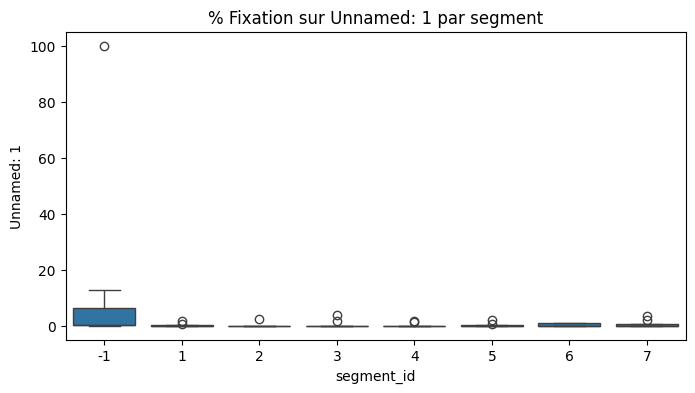

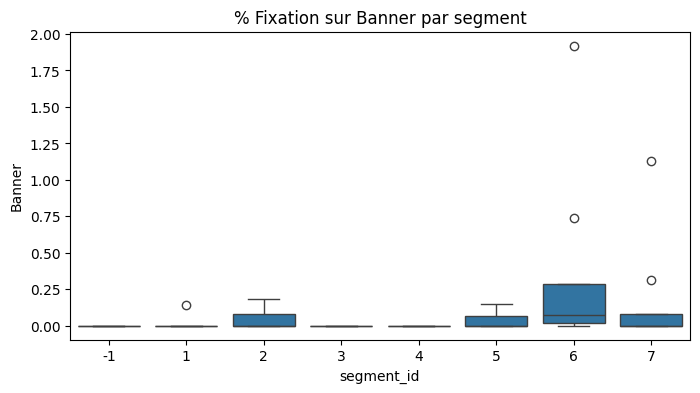

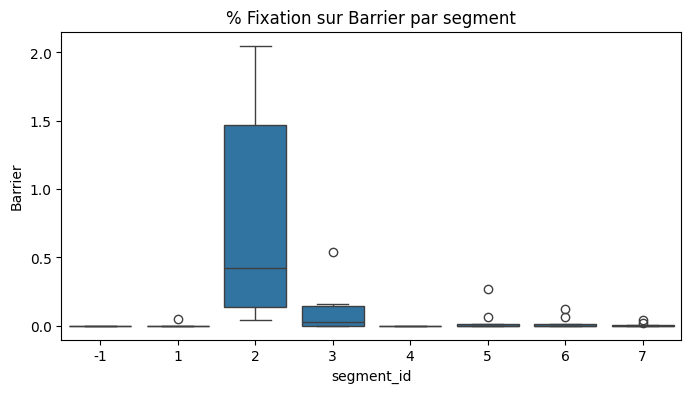

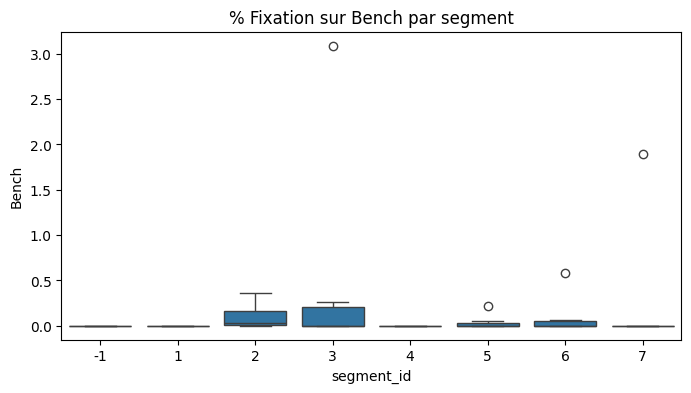

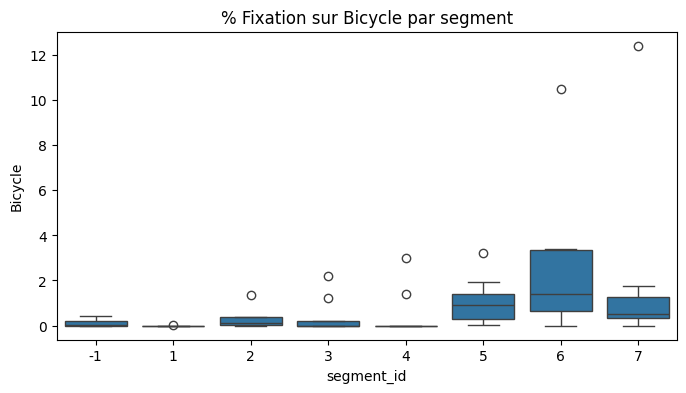

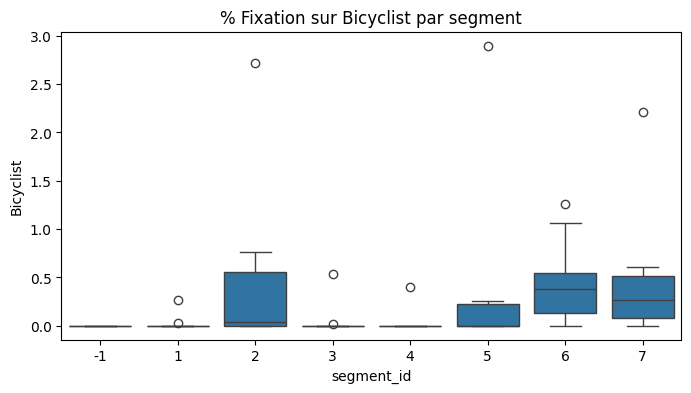

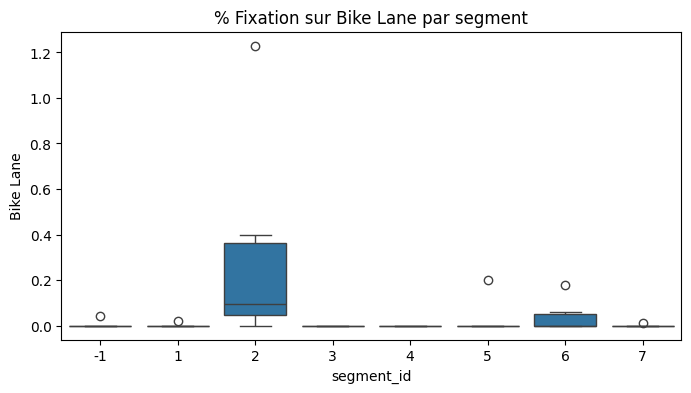

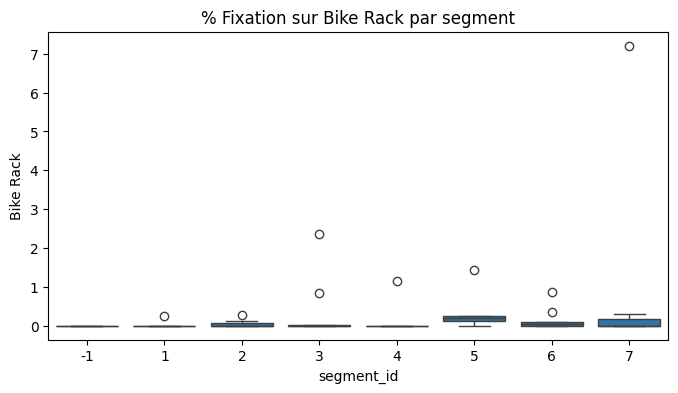

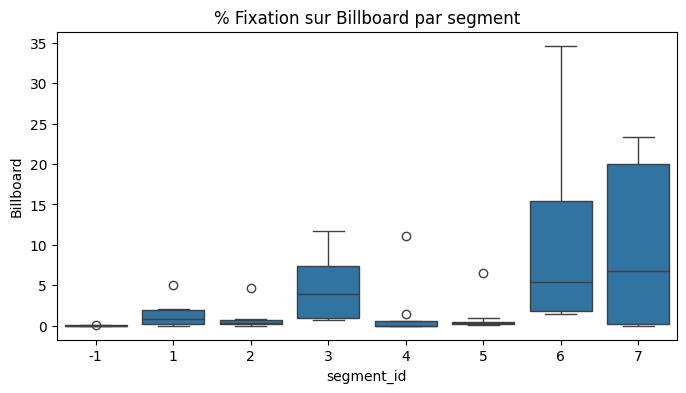

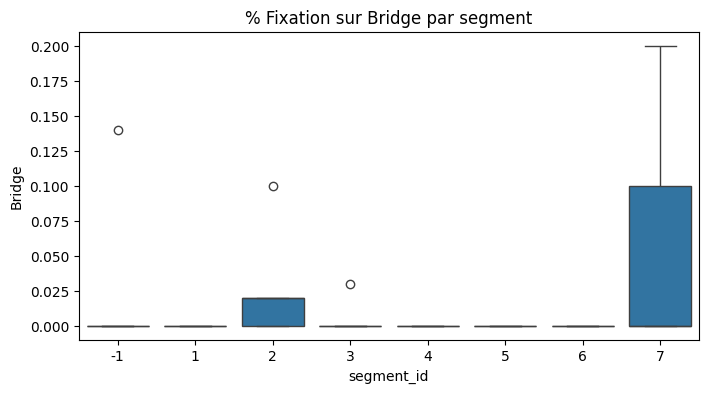

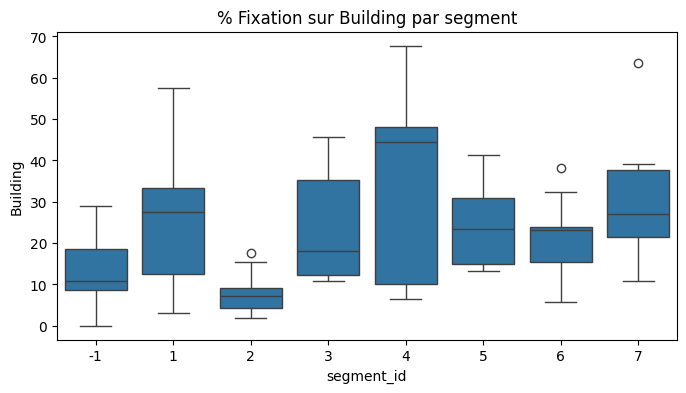

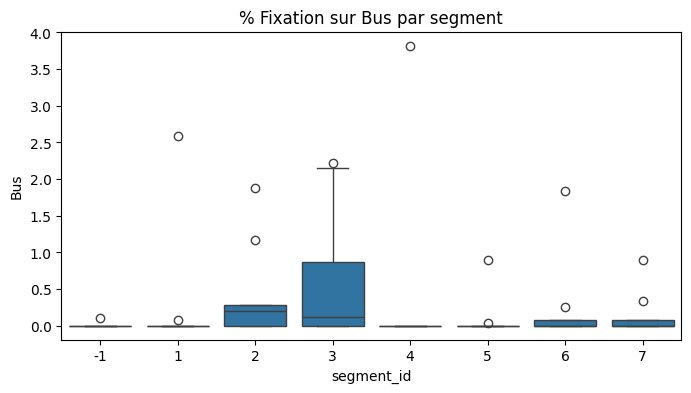

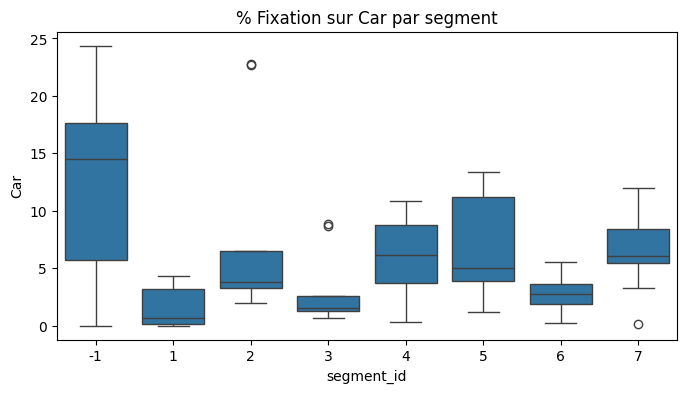

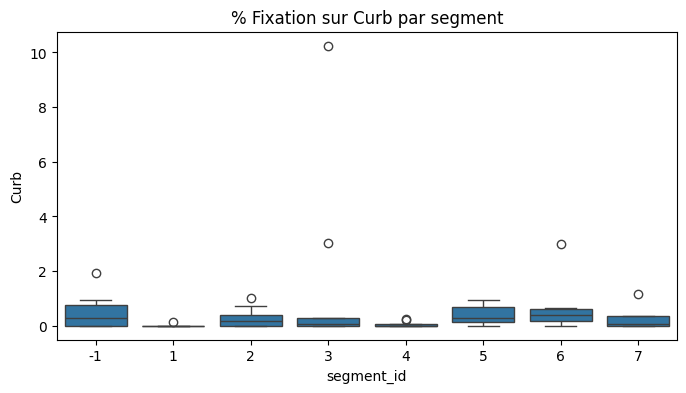

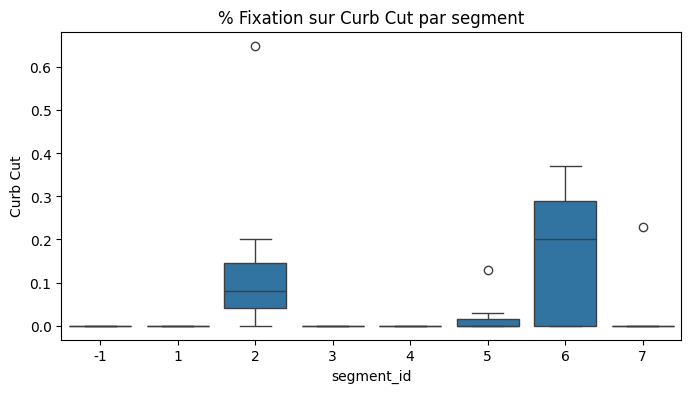

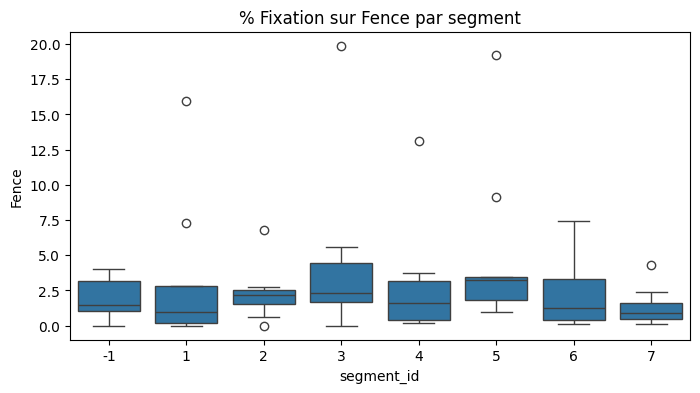

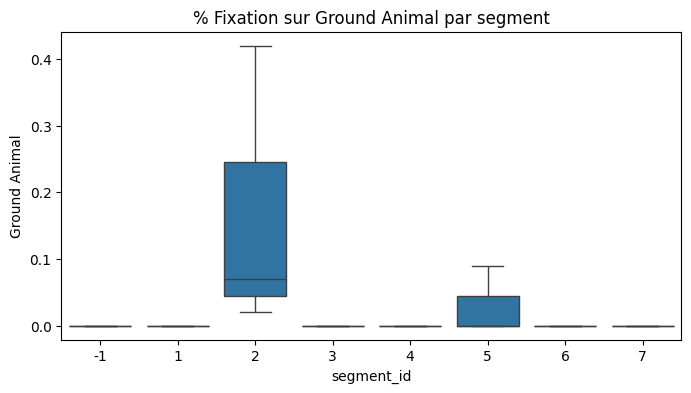

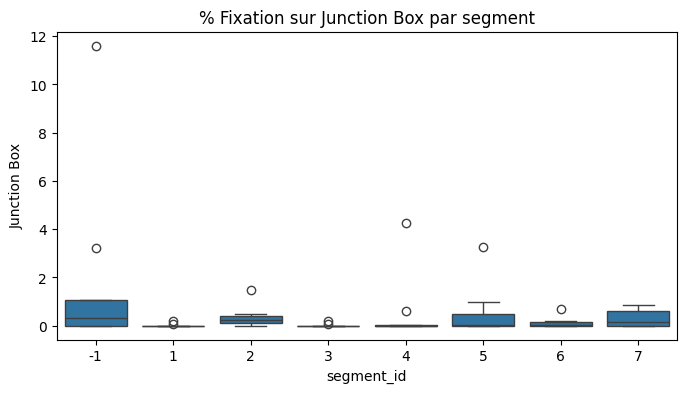

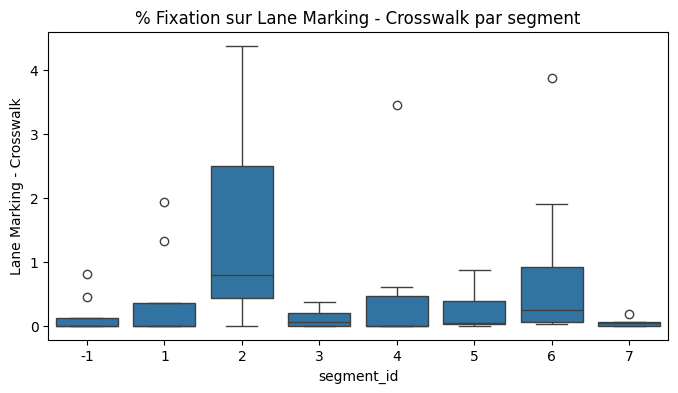

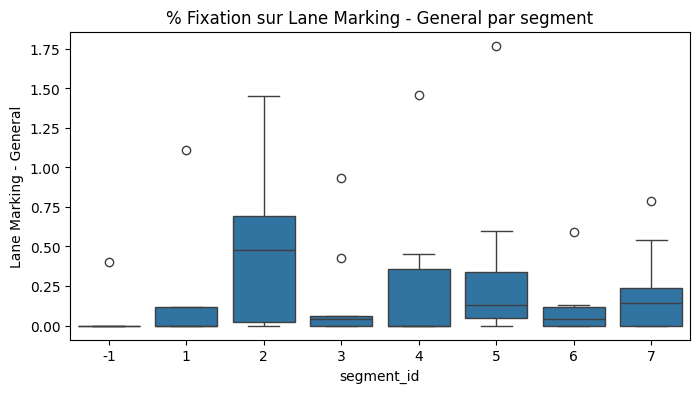

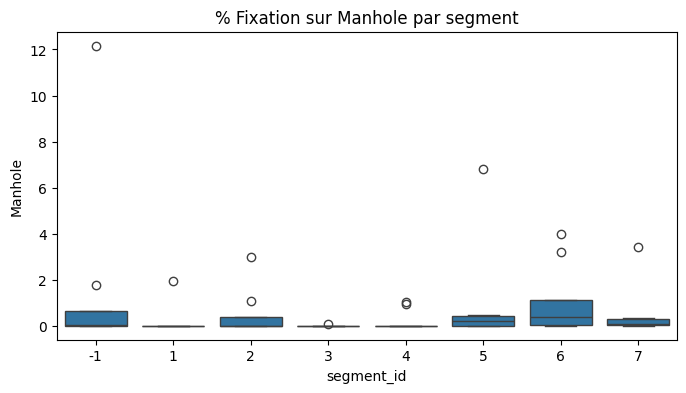

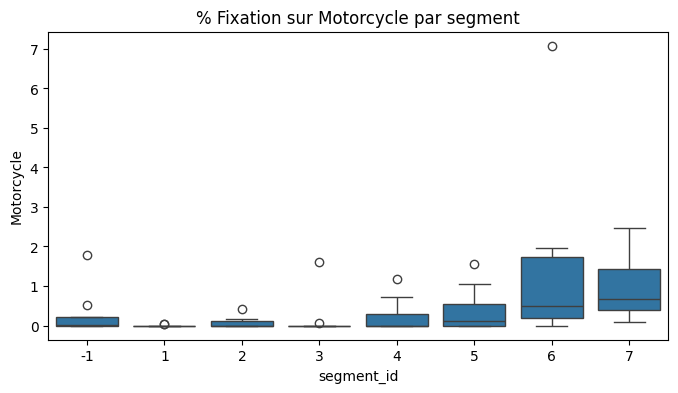

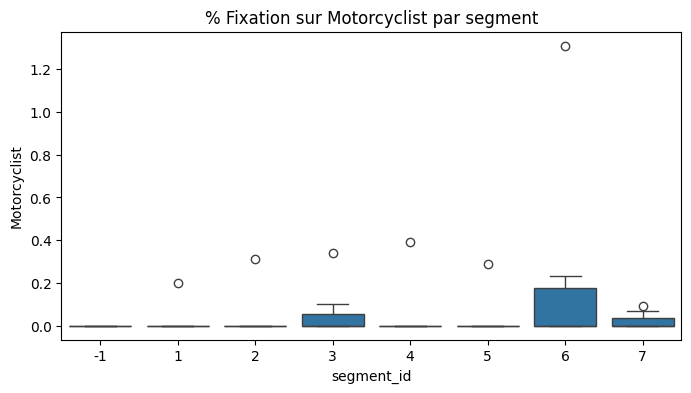

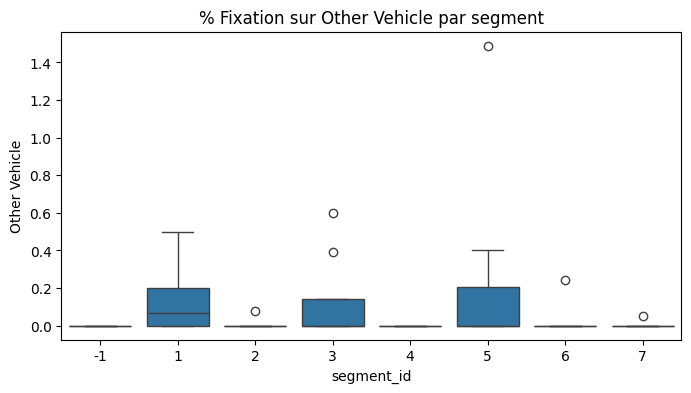

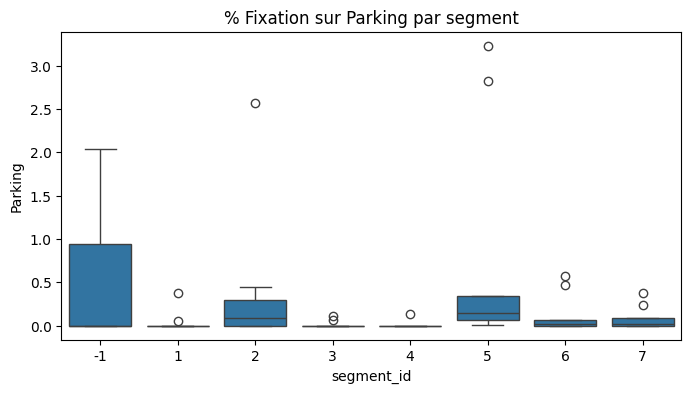

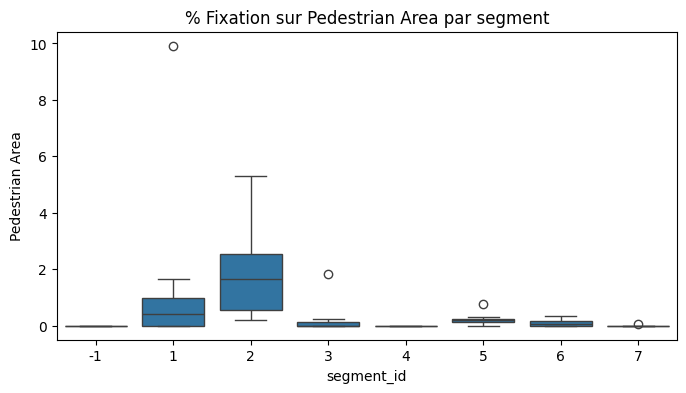

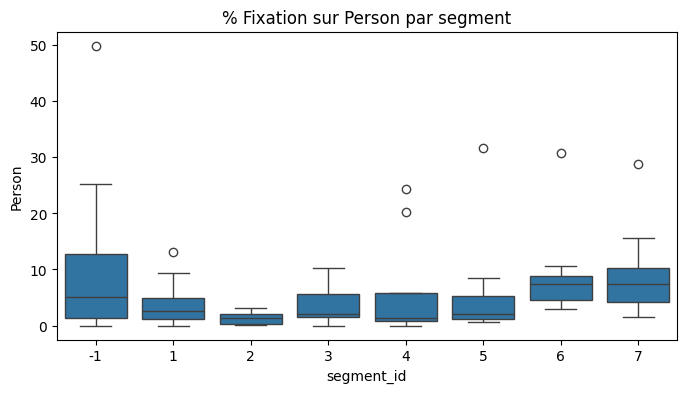

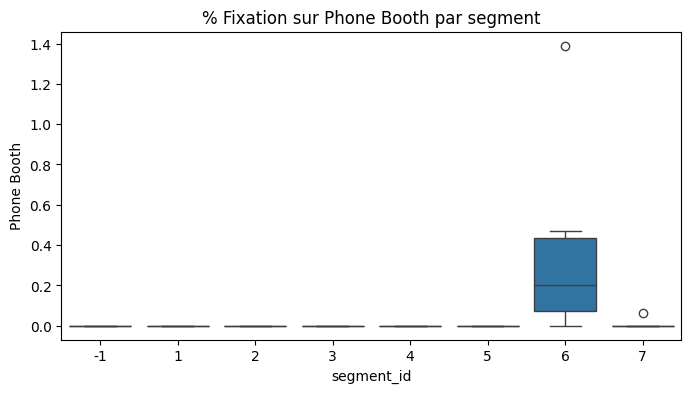

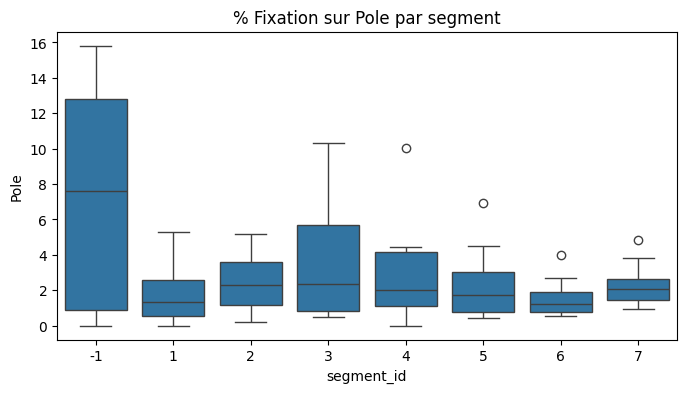

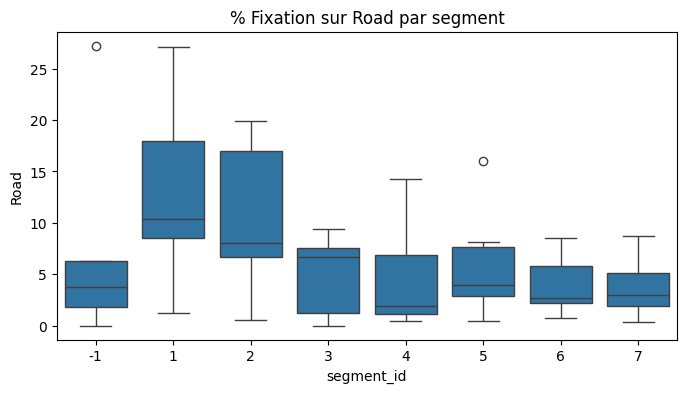

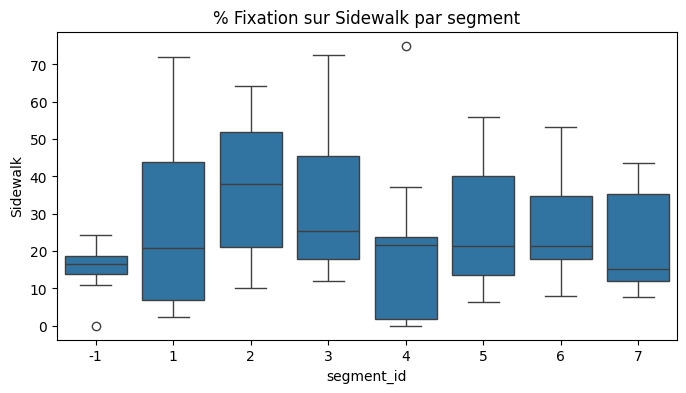

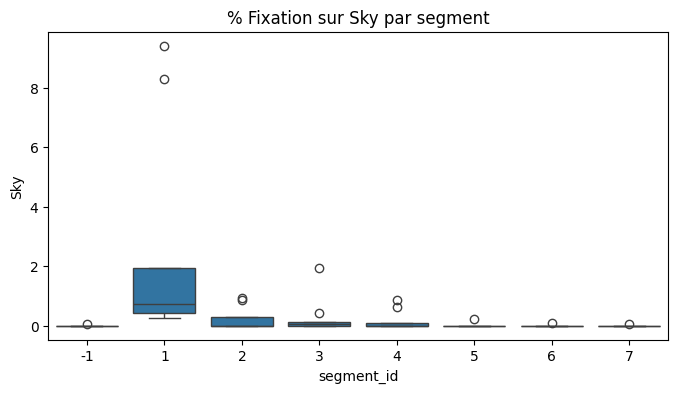

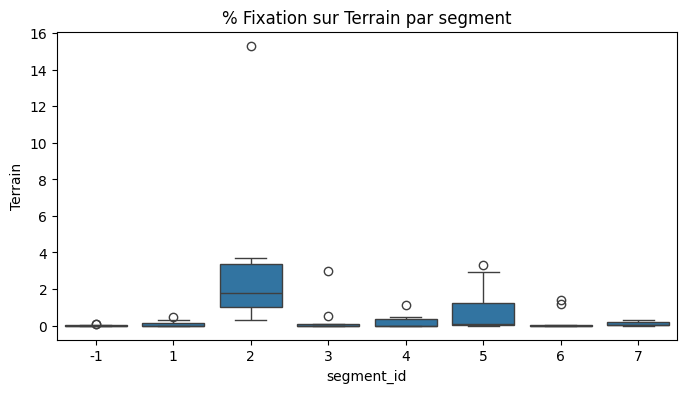

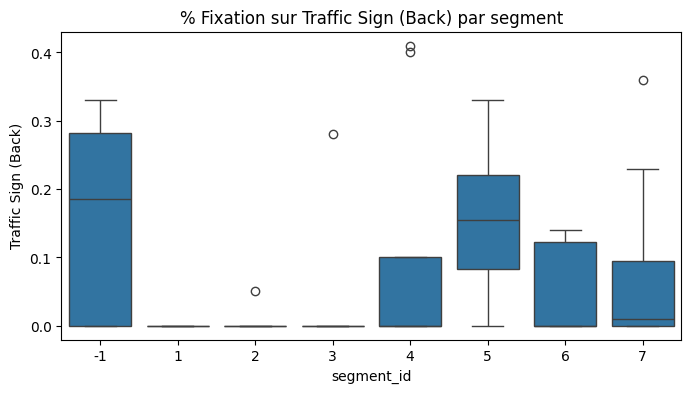

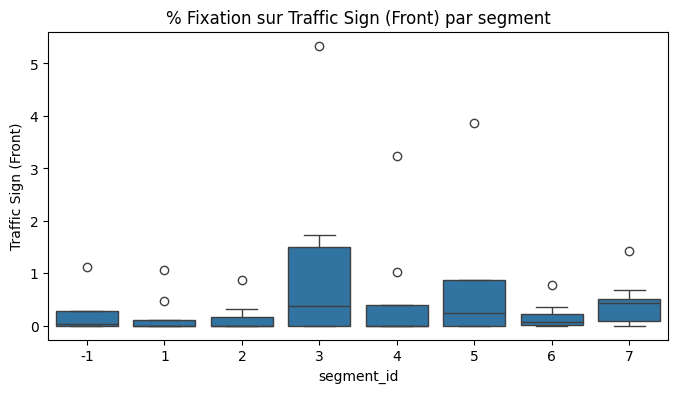

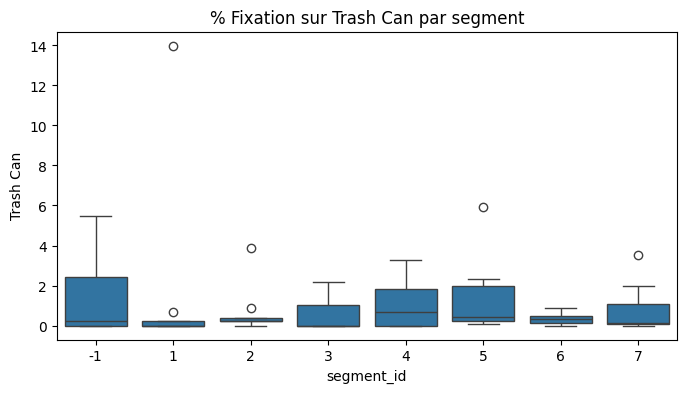

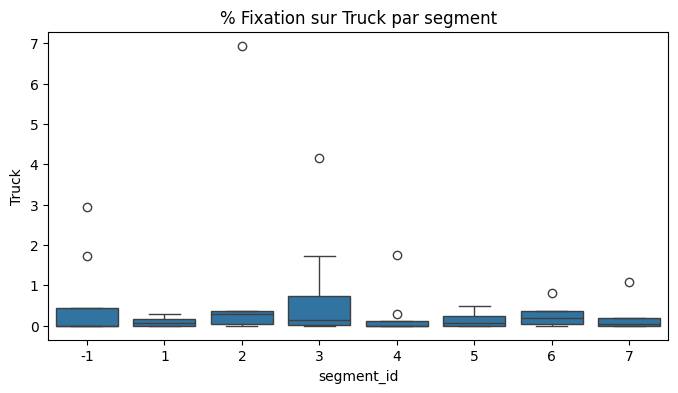

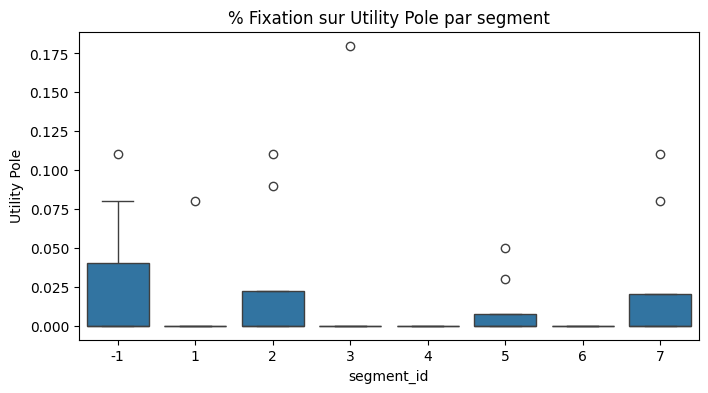

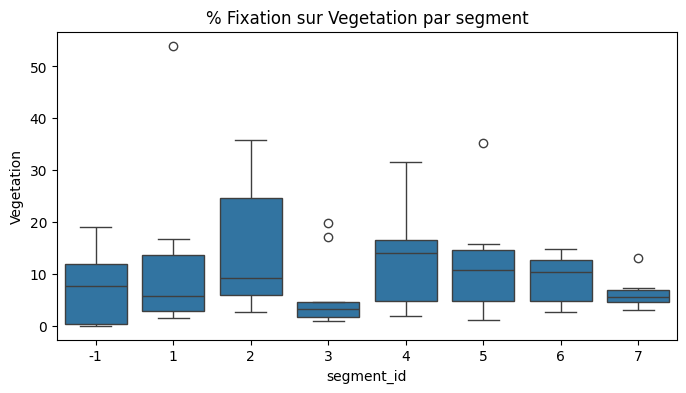

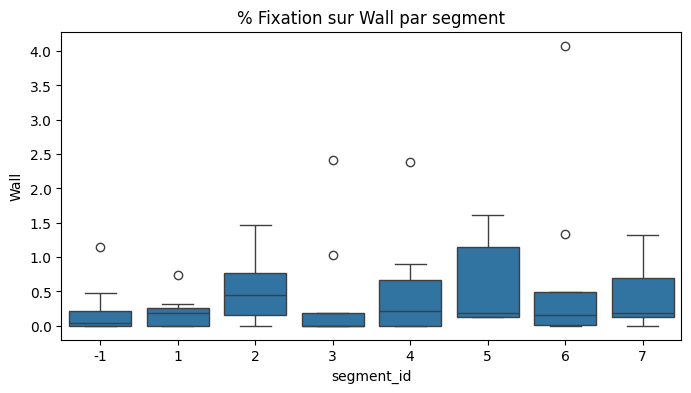

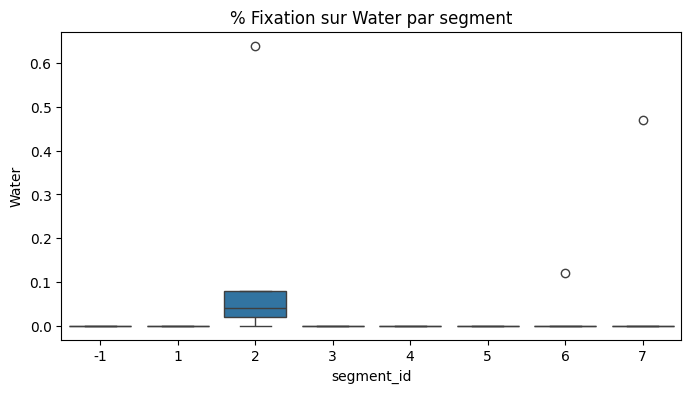

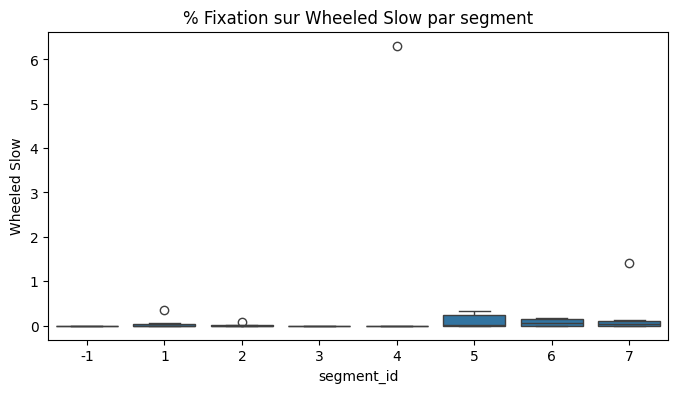

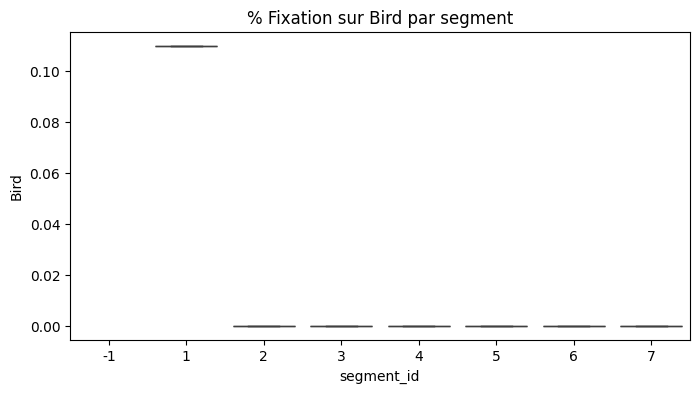

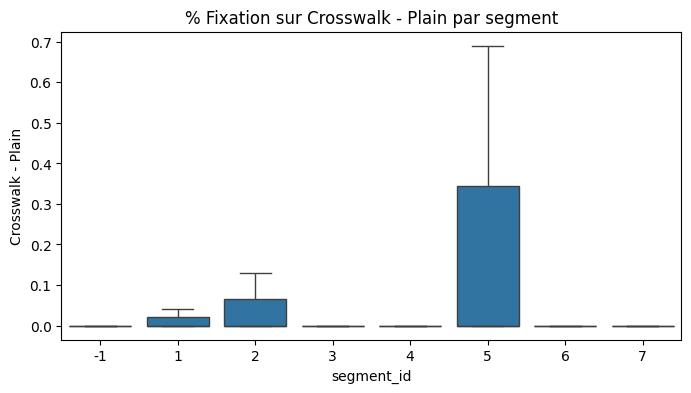

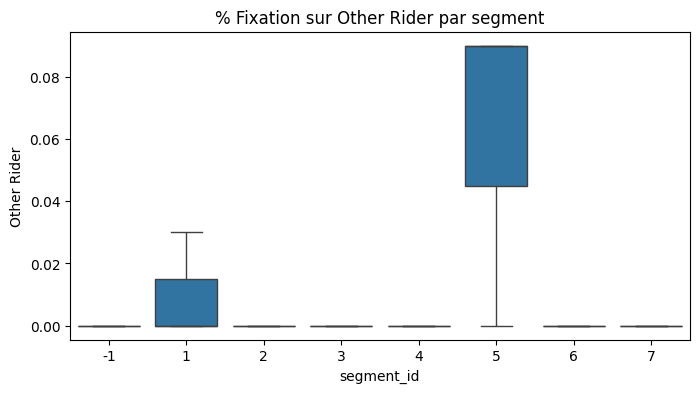

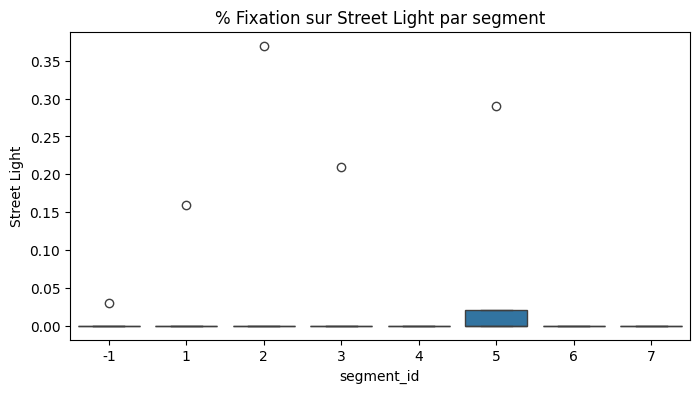

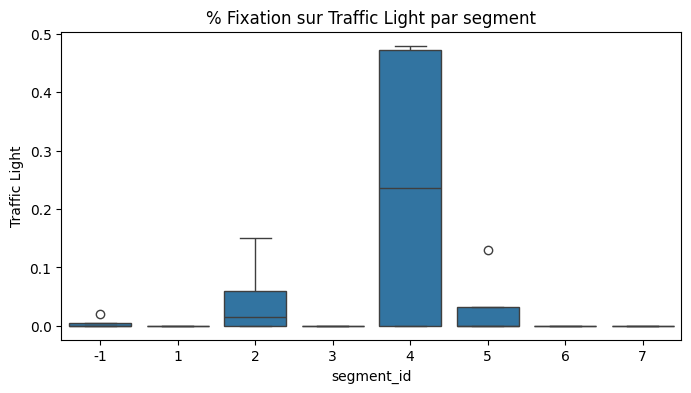

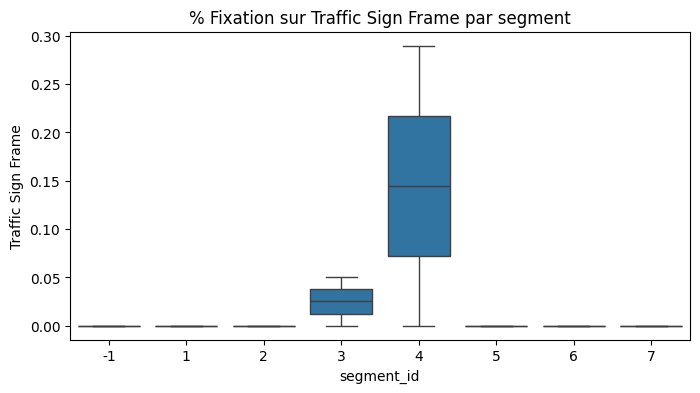

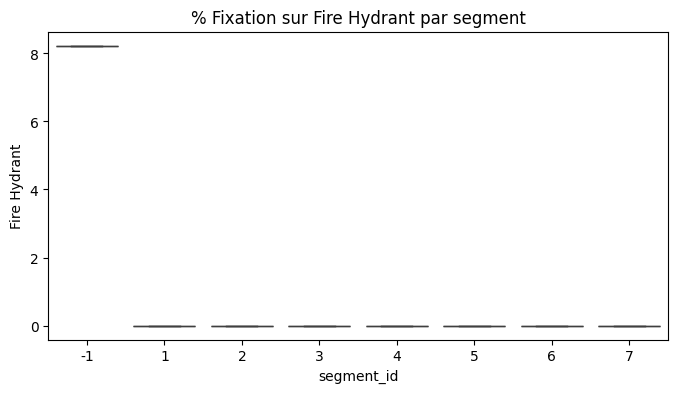

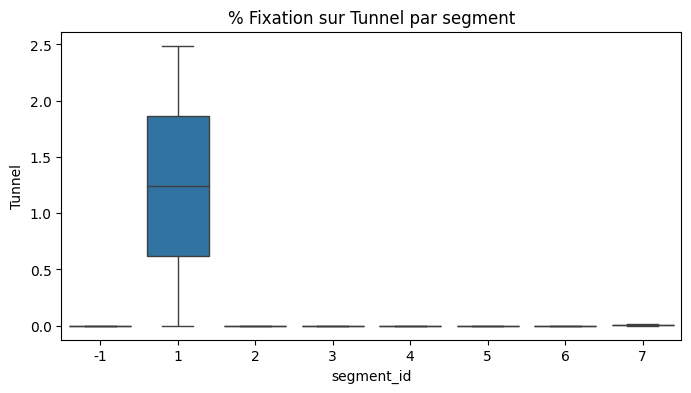

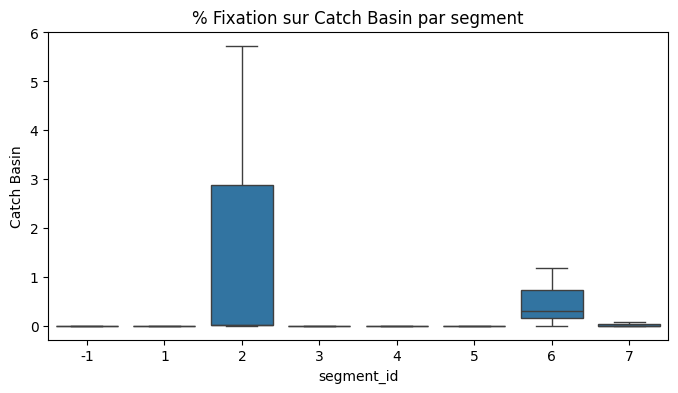

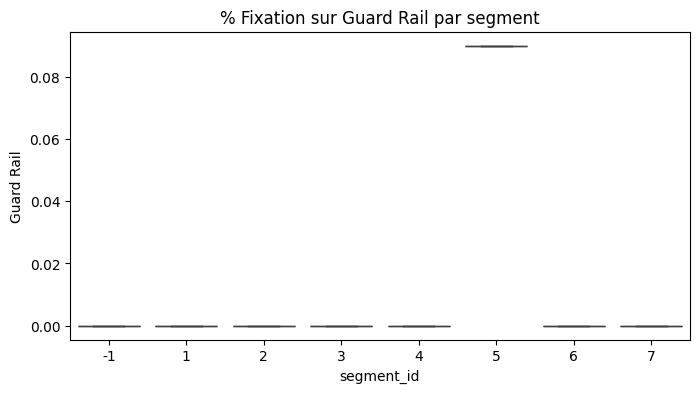

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in feature_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_gaze_all, x="segment_id", y=feature)
    plt.title(f"% Fixation sur {feature} par segment")
    plt.show()


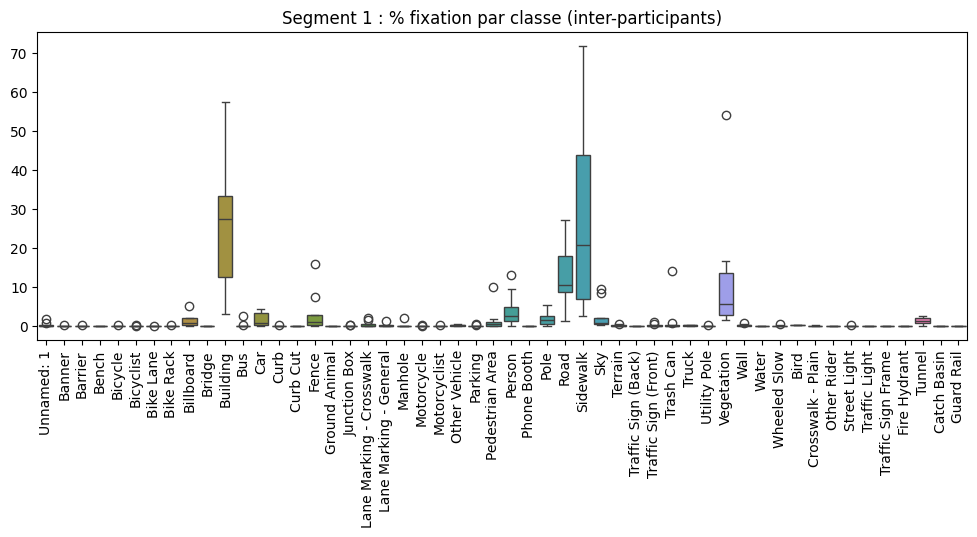

In [ ]:
# exemple pour le segment 1
segment_1 = df_gaze_all[df_gaze_all["segment_id"] == 1]
plt.figure(figsize=(12,4))
sns.boxplot(data=segment_1[feature_cols])
plt.title("Segment 1 : % fixation par classe (inter-participants)")
plt.xticks(rotation=90)
plt.show()


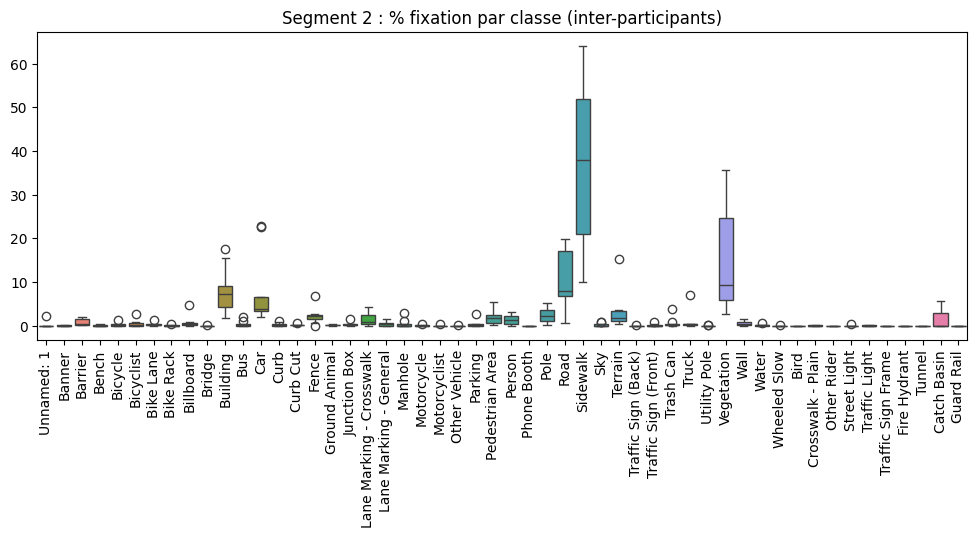

In [ ]:
segment_1 = df_gaze_all[df_gaze_all["segment_id"] == 2]
plt.figure(figsize=(12,4))
sns.boxplot(data=segment_1[feature_cols])
plt.title("Segment 2 : % fixation par classe (inter-participants)")
plt.xticks(rotation=90)
plt.show()

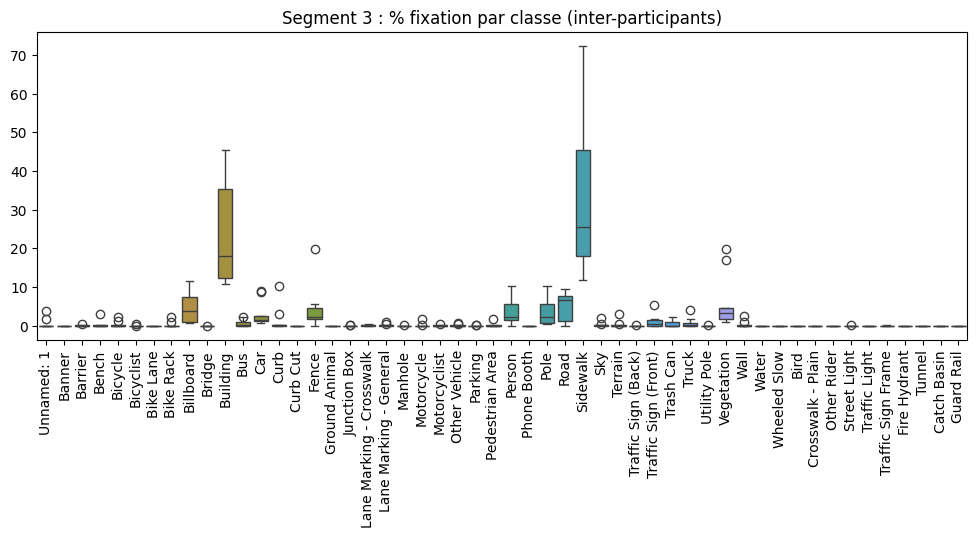

In [ ]:
segment_1 = df_gaze_all[df_gaze_all["segment_id"] == 3]
plt.figure(figsize=(12,4))
sns.boxplot(data=segment_1[feature_cols])
plt.title("Segment 3 : % fixation par classe (inter-participants)")
plt.xticks(rotation=90)
plt.show()

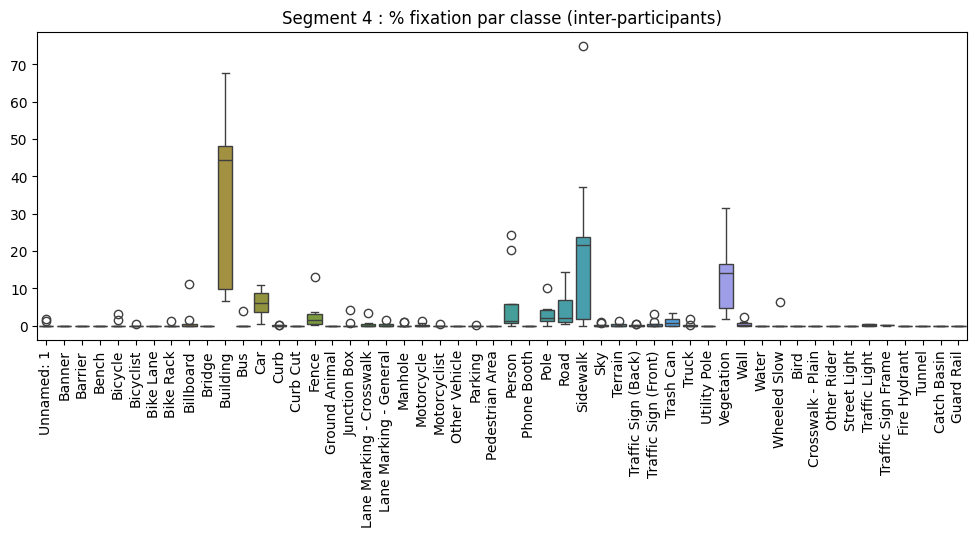

In [ ]:
segment_1 = df_gaze_all[df_gaze_all["segment_id"] == 4]
plt.figure(figsize=(12,4))
sns.boxplot(data=segment_1[feature_cols])
plt.title("Segment 4 : % fixation par classe (inter-participants)")
plt.xticks(rotation=90)
plt.show()

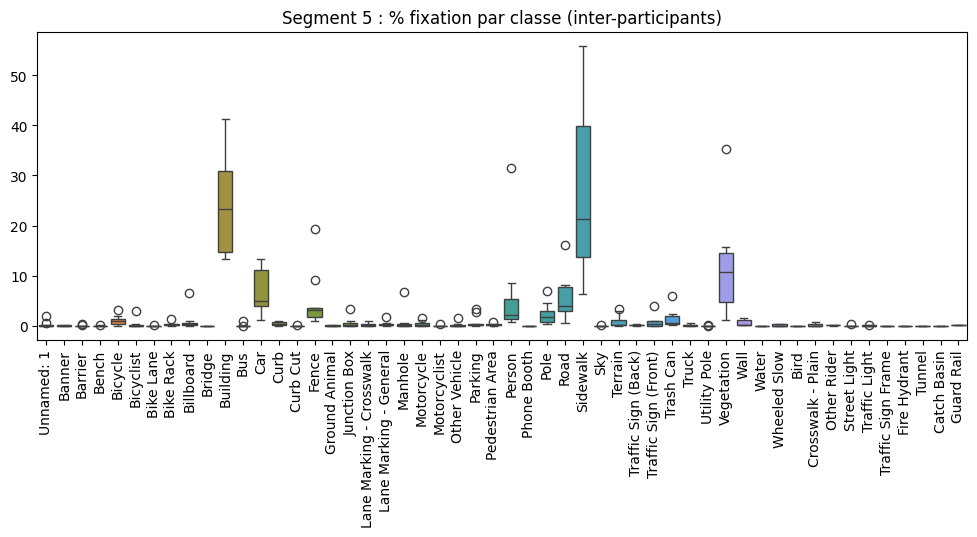

In [ ]:
segment_1 = df_gaze_all[df_gaze_all["segment_id"] == 5]
plt.figure(figsize=(12,4))
sns.boxplot(data=segment_1[feature_cols])
plt.title("Segment 5 : % fixation par classe (inter-participants)")
plt.xticks(rotation=90)
plt.show()

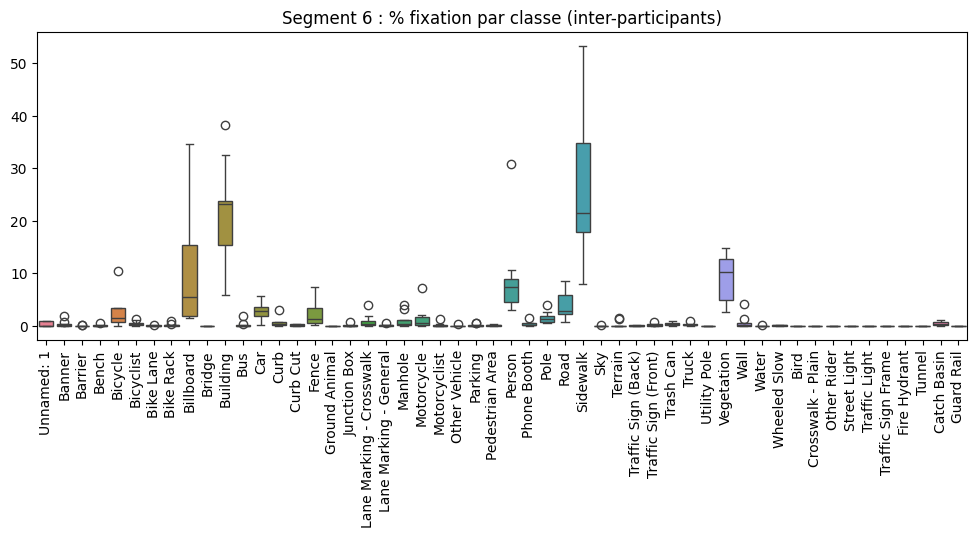

In [ ]:
segment_1 = df_gaze_all[df_gaze_all["segment_id"] == 6]
plt.figure(figsize=(12,4))
sns.boxplot(data=segment_1[feature_cols])
plt.title("Segment 6 : % fixation par classe (inter-participants)")
plt.xticks(rotation=90)
plt.show()

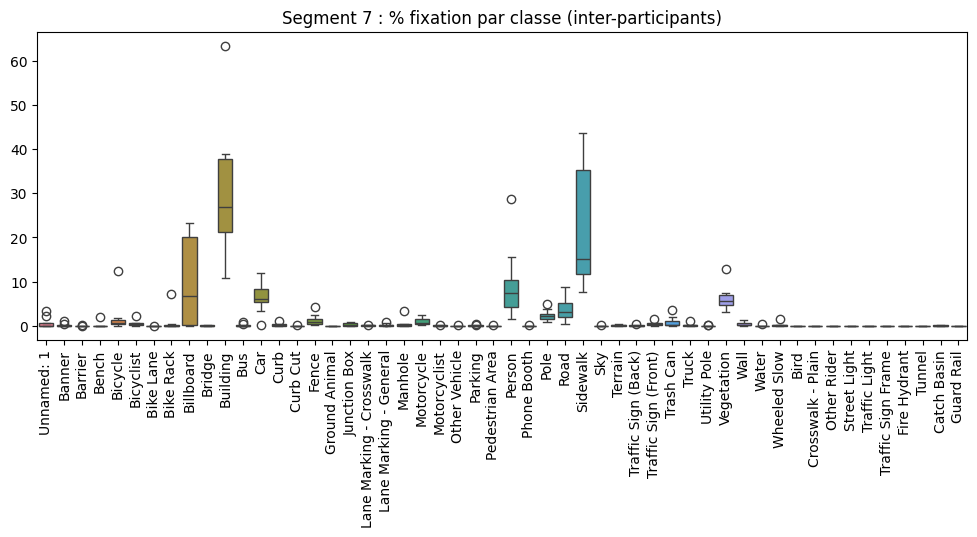

In [ ]:
segment_1 = df_gaze_all[df_gaze_all["segment_id"] == 7]
plt.figure(figsize=(12,4))
sns.boxplot(data=segment_1[feature_cols])
plt.title("Segment 7 : % fixation par classe (inter-participants)")
plt.xticks(rotation=90)
plt.show()

Viewport analysis


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
participant_id = "P01"
csv_file = f"{participant_id}_viewport_features_optimised.csv"

df = pd.read_csv(csv_file)


In [3]:
# Sélection des colonnes features (moyennes et écart-types)
feature_cols = [c for c in df.columns if ("_mean" in c or "_std" in c)]

# Corrélation avec walkability_rating
corr_with_walk = df[feature_cols + ["walkability_rating"]].corr()["walkability_rating"].sort_values(ascending=False)

print("\nCorrélations avec walkability_rating ")
print(corr_with_walk)


Corrélations avec walkability_rating 
walkability_rating    1.000000
Sidewalk_mean         0.471635
Wall_std              0.417160
Road_std              0.381634
Bus_mean              0.381267
                        ...   
Car Mount_mean       -0.861004
Car Mount_std        -0.876056
Traffic Light_mean   -0.883528
Service Lane_mean          NaN
Service Lane_std           NaN
Name: walkability_rating, Length: 121, dtype: float64


In [4]:

top_10_corr = corr_with_walk.drop("walkability_rating").abs().sort_values(ascending=False).head(10)
print("\nTop 10 features les plus corrélées avec walkability_rating :")
print(top_10_corr)

# 2️⃣ Corrélation pour les 6 classes qui t'intéressent
interesting_classes = ["Vegetation", "Building", "Sky", "Road", "Sidewalk", "Car"]

# Récupérer mean et std pour chaque classe
corr_interesting = {}
for cls in interesting_classes:
    for suffix in ["_mean", "_std"]:
        col = cls + suffix
        if col in corr_with_walk:
            corr_interesting[col] = corr_with_walk[col]

print("\nCorrélation des 6 classes sélectionnées avec walkability_rating :")
for k, v in corr_interesting.items():
    print(f"{k}: {v:.3f}")



Top 10 features les plus corrélées avec walkability_rating :
Traffic Light_mean          0.883528
Car Mount_std               0.876056
Car Mount_mean              0.861004
Traffic Light_std           0.860951
Pole_mean                   0.851956
Traffic Sign (Back)_std     0.815006
Traffic Sign (Back)_mean    0.790160
Utility Pole_std            0.780880
Utility Pole_mean           0.779108
Rail Track_mean             0.775028
Name: walkability_rating, dtype: float64

Corrélation des 6 classes sélectionnées avec walkability_rating :
Vegetation_mean: 0.037
Vegetation_std: -0.289
Building_mean: -0.076
Building_std: -0.165
Sky_mean: 0.057
Sky_std: -0.262
Road_mean: -0.090
Road_std: 0.382
Sidewalk_mean: 0.472
Sidewalk_std: 0.250
Car_mean: -0.748
Car_std: -0.737


In [5]:
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr

#Charger tous les participants
data_dir = Path("/content/viewport")  # dossier avec tous les CSV

dfs = []

for file in data_dir.glob("*.csv"):
    df = pd.read_csv(file)
    dfs.append(df)

# concat tous les participants
df_all = pd.concat(dfs, ignore_index=True)

print("Shape:", df_all.shape)

# Sélection des features
feature_cols = [c for c in df_all.columns if ("_mean" in c or "_std" in c)]

#  Corrélation avec walkability

results = []

for col in feature_cols:
    try:
        corr, pval = pearsonr(df_all[col], df_all['walkability_rating'])
        results.append({
            'feature': col,
            'correlation': corr,
            'p_value': pval
        })
    except:
        continue

df_corr = pd.DataFrame(results)

# Trier les plus corrélées

df_corr_sorted = df_corr.sort_values(by='correlation', ascending=False)

print("\nTop 10 positive correlations:")
print(df_corr_sorted.head(10))

print("\nTop 10 negative correlations:")
print(df_corr_sorted.tail(10))

df_corr_sorted.to_csv("/content/correlation_results.csv", index=False)

Shape: (63, 124)

Top 10 positive correlations:
               feature  correlation   p_value
52     Vegetation_mean     0.421860  0.000574
71    Junction Box_std     0.258375  0.040896
113          Truck_std     0.251471  0.046802
70   Junction Box_mean     0.250478  0.047705
112         Truck_mean     0.246744  0.051235
50        Terrain_mean     0.240581  0.057523
100           Car_mean     0.224888  0.076390
51         Terrain_std     0.222563  0.079563
72        Mailbox_mean     0.212279  0.094866
58          Bench_mean     0.206953  0.103649

Top 10 negative correlations:
                 feature  correlation   p_value
4             Fence_mean    -0.344611  0.005679
42      Other Rider_mean    -0.348861  0.005076
48              Sky_mean    -0.353041  0.004539
20  Pedestrian Area_mean    -0.356988  0.004078
43       Other Rider_std    -0.374187  0.002518
49               Sky_std    -0.402160  0.001086
21   Pedestrian Area_std    -0.420644  0.000598
24             Road_mean    -0.

In [8]:
classes_of_interest = [
    "Vegetation",
    "Building",
    "Road",
    "Sidewalk",
    "Sky",
    "Car"
]

# garder seulement les features qui contiennent ces classes
df_6 = df_corr[
    df_corr['feature'].apply(lambda x: any(c in x for c in classes_of_interest))
]

# trier par corrélation
df_6 = df_6.sort_values(by='correlation', ascending=False)

print(df_6)

             feature  correlation   p_value
52   Vegetation_mean     0.421860  0.000574
100         Car_mean     0.224888  0.076390
53    Vegetation_std     0.203921  0.108922
101          Car_std     0.113139  0.377307
102     Caravan_mean    -0.000008  0.999947
32     Building_mean    -0.005849  0.963713
103      Caravan_std    -0.036746  0.774942
117    Car Mount_std    -0.136325  0.286713
33      Building_std    -0.182363  0.152573
28     Sidewalk_mean    -0.183786  0.149343
116   Car Mount_mean    -0.206379  0.104632
48          Sky_mean    -0.353041  0.004539
49           Sky_std    -0.402160  0.001086
24         Road_mean    -0.451622  0.000203
29      Sidewalk_std    -0.461212  0.000142
25          Road_std    -0.544925  0.000004


In [ ]:
participant_id = "P01"
csv_file = f"{participant_id}_viewport_features.csv"

df = pd.read_csv(csv_file)

In [ ]:
df


,participant_id,segment_id,walkability_rating,entropy,building_mean,building_std,vegetation_mean,vegetation_std,car_mean,car_std,road_mean,road_std,sidewalk_mean,sidewalk_std,sky_mean,sky_std
0,P01,1,4.0,0.150589,0.000005,0.000213,0.001921,0.003264,0.024385,0.019544,0.000009,0.000124,0.001077,0.002659,0.008491,0.026078
1,P01,2,3.2,0.180286,0.000016,0.000112,0.008279,0.005872,0.022220,0.035818,0.000026,0.000257,0.001944,0.003797,0.009279,0.011802
2,P01,3,3.2,0.139637,0.000071,0.001349,0.010007,0.006123,0.017030,0.032621,0.000101,0.000443,0.001925,0.002268,0.001647,0.004585
3,P01,4,3.8,0.049963,0.000002,0.000031,0.001210,0.001248,0.002583,0.004511,0.000000,0.000000,0.000230,0.000832,0.004540,0.016396
4,P01,5,3.8,0.111553,0.000001,0.000028,0.010481,0.008739,0.010809,0.016484,0.000002,0.000061,0.000297,0.001521,0.001993,0.004787
5,P01,6,3.7,0.084345,0.000022,0.000406,0.005892,0.006958,0.006033,0.011428,0.000003,0.000054,0.000837,0.006419,0.002924,0.004581
6,P01,7,2.5,0.091800,0.000030,0.000219,0.006981,0.006007,0.011300,0.023673,0.000003,0.000112,0.000003,0.000073,0.000865,0.008183


In [ ]:
# Sélection des colonnes features (moyennes et écart-types)
feature_cols = [c for c in df.columns if ("_mean" in c or "_std" in c)]

# Corrélation avec walkability_rating
corr_with_walk = df[feature_cols + ["walkability_rating"]].corr()["walkability_rating"].sort_values(ascending=False)

print("\nCorrélations avec walkability_rating ")
print(corr_with_walk)



Corrélations avec walkability_rating 
walkability_rating    1.000000
sky_std               0.417160
sky_mean              0.370505
sidewalk_std          0.329334
sidewalk_mean        -0.011707
car_mean             -0.063564
building_std         -0.240927
vegetation_std       -0.252224
road_mean            -0.257955
road_std             -0.389850
vegetation_mean      -0.426196
building_mean        -0.544476
car_std              -0.562737
Name: walkability_rating, dtype: float64


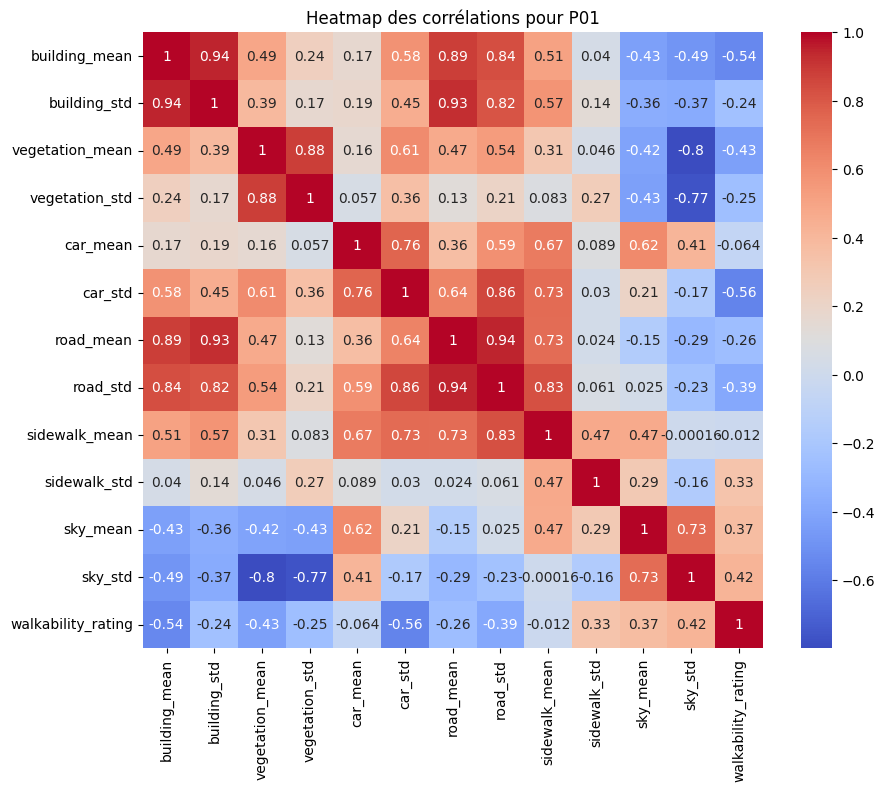

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols + ["walkability_rating"]].corr(), annot=True, cmap="coolwarm")
plt.title(f"Heatmap des corrélations pour {participant_id}")
plt.show()


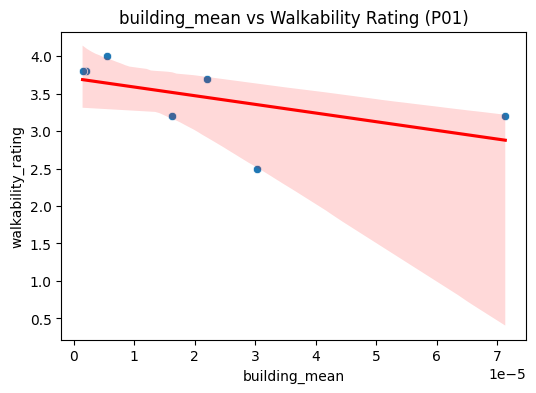

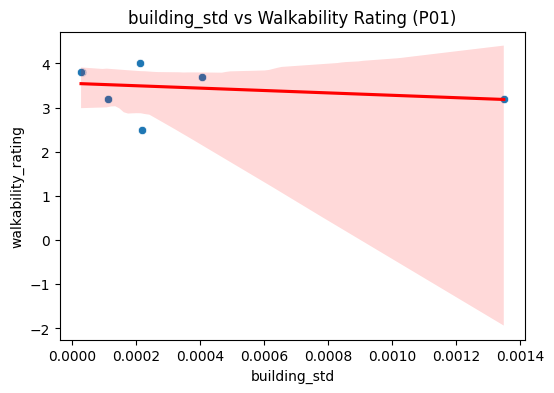

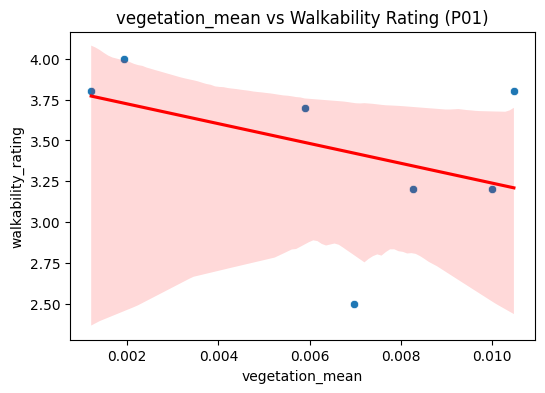

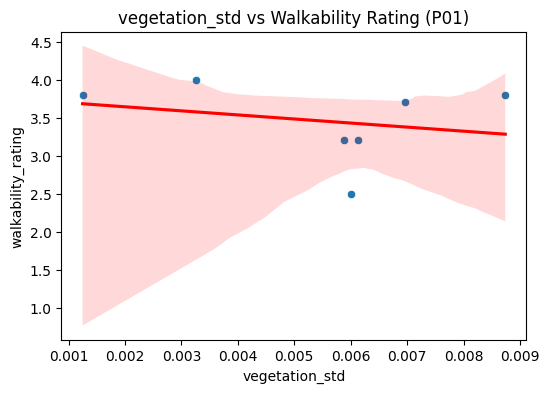

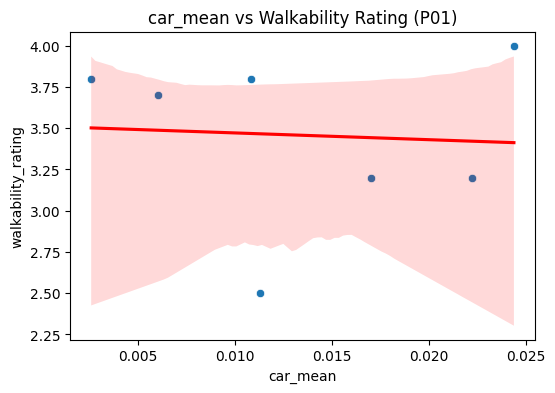

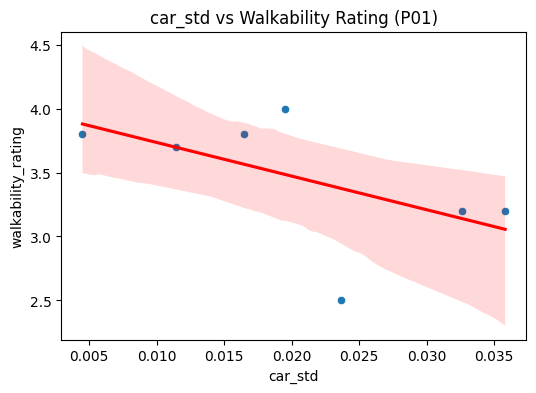

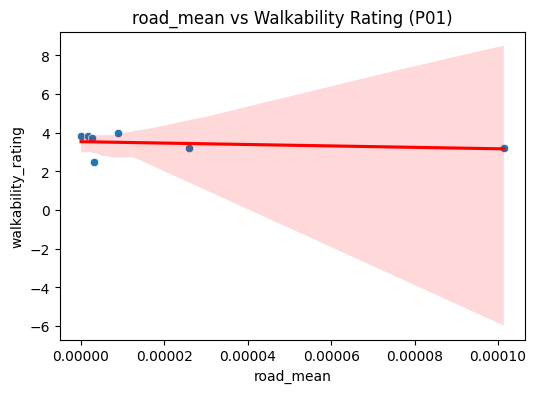

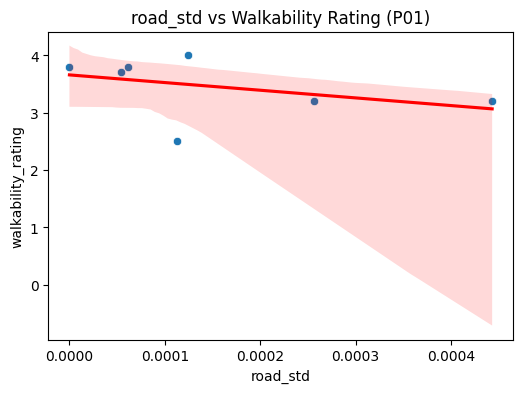

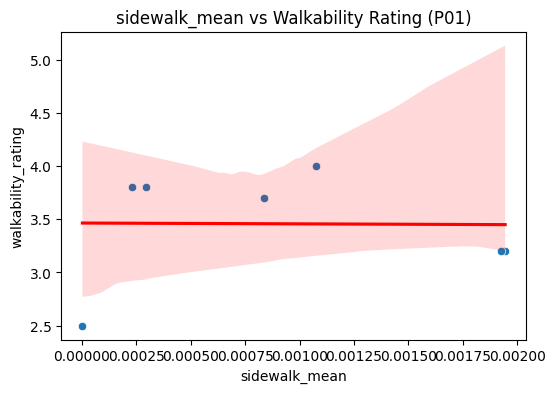

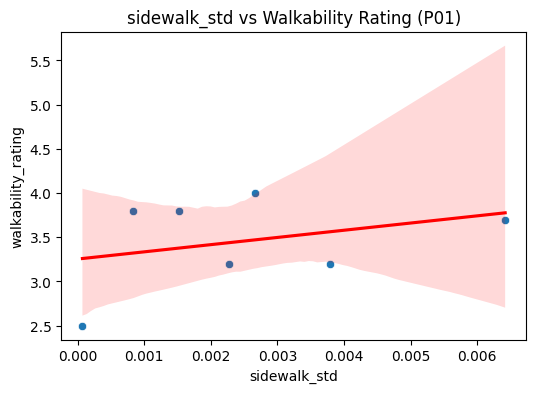

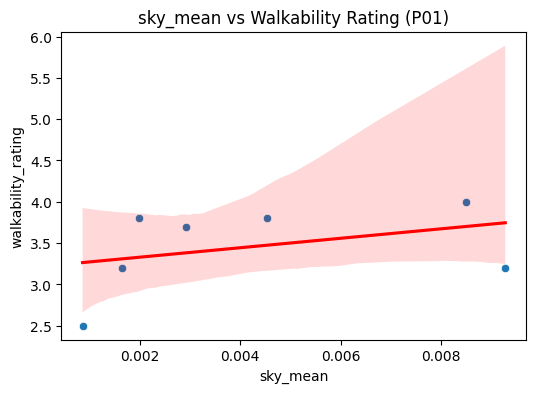

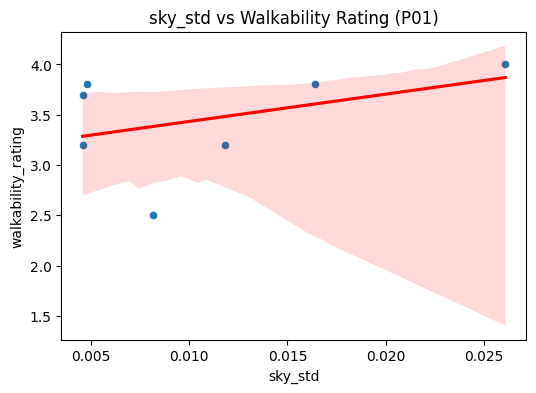

In [ ]:
for feature in feature_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=feature, y="walkability_rating")
    sns.regplot(data=df, x=feature, y="walkability_rating", scatter=False, color="red")
    plt.title(f"{feature} vs Walkability Rating ({participant_id})")
    plt.show()


In [ ]:
participant_id = "P02"
csv_file = f"{participant_id}_viewport_features.csv"

df = pd.read_csv(csv_file)
df




,participant_id,segment_id,walkability_rating,entropy,building_mean,building_std,vegetation_mean,vegetation_std,car_mean,car_std,road_mean,road_std,sidewalk_mean,sidewalk_std,sky_mean,sky_std
0,P02,1,1.8,0.144876,1.005990e-06,2.514338e-05,0.003480,0.005036,0.023843,0.021428,2.928874e-06,4.850113e-05,0.001236,0.003681,0.005300,0.009861
1,P02,2,4.0,0.199965,2.964076e-06,5.088435e-05,0.007739,0.006411,0.033204,0.041928,9.528775e-05,1.513508e-03,0.002443,0.003924,0.006733,0.007446
2,P02,3,3.4,0.117732,5.812274e-07,1.000375e-05,0.010585,0.011767,0.012110,0.019852,1.784975e-04,1.601257e-03,0.000851,0.002227,0.001290,0.003405
3,P02,4,3.9,0.036641,1.837155e-09,4.209450e-08,0.000976,0.001205,0.002098,0.002990,2.939447e-08,6.527640e-07,0.000305,0.000741,0.002398,0.005435
4,P02,5,3.9,0.086000,1.178103e-05,1.547225e-04,0.009527,0.008684,0.005097,0.008654,3.450677e-06,7.771741e-05,0.000885,0.003222,0.001252,0.003167
5,P02,6,3.6,0.057679,3.477787e-08,1.228599e-06,0.006183,0.009867,0.001357,0.002821,0.000000e+00,0.000000e+00,0.001146,0.009313,0.001457,0.006420
6,P02,7,3.9,0.081358,5.045862e-05,1.697587e-03,0.012145,0.008481,0.003973,0.009706,0.000000e+00,0.000000e+00,0.000029,0.000661,0.000691,0.003773



Corrélations avec walkability_rating 
walkability_rating    1.000000
vegetation_mean       0.353062
building_mean         0.284452
building_std          0.245992
road_std              0.155944
vegetation_std        0.110651
road_mean             0.079644
sidewalk_mean        -0.100003
sidewalk_std         -0.127128
car_std              -0.133327
sky_mean             -0.356122
car_mean             -0.356379
sky_std              -0.677375
Name: walkability_rating, dtype: float64


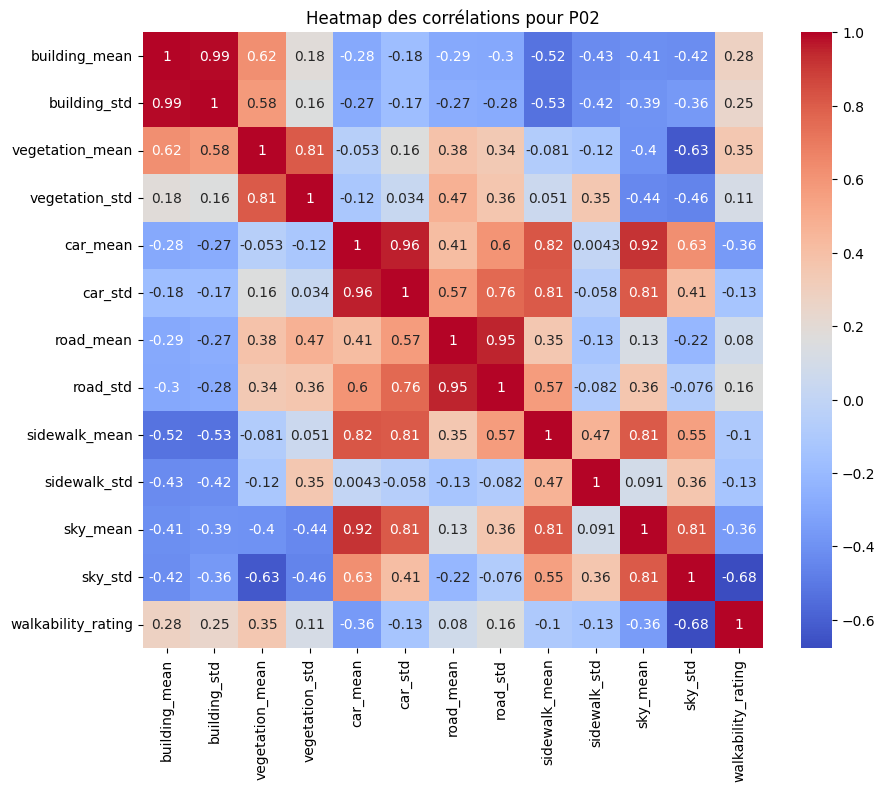

In [ ]:
# Sélection des colonnes features (moyennes et écart-types)
feature_cols = [c for c in df.columns if ("_mean" in c or "_std" in c)]

# Corrélation avec walkability_rating
corr_with_walk = df[feature_cols + ["walkability_rating"]].corr()["walkability_rating"].sort_values(ascending=False)

print("\nCorrélations avec walkability_rating ")
print(corr_with_walk)
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols + ["walkability_rating"]].corr(), annot=True, cmap="coolwarm")
plt.title(f"Heatmap des corrélations pour {participant_id}")
plt.show()



In [ ]:
participant_id = "P03"
csv_file = f"{participant_id}_viewport_features.csv"

df = pd.read_csv(csv_file)
df

,participant_id,segment_id,walkability_rating,entropy,building_mean,building_std,vegetation_mean,vegetation_std,car_mean,car_std,road_mean,road_std,sidewalk_mean,sidewalk_std,sky_mean,sky_std
0,P03,1,2.5,0.162313,2.512182e-08,0.000001,0.002676,0.003158,0.024130,0.013616,0.000001,0.000033,0.000958,0.002490,0.011090,0.024581
1,P03,2,4.0,0.170191,2.217463e-06,0.000034,0.008078,0.006605,0.016043,0.016251,0.000018,0.000225,0.003446,0.004645,0.009768,0.006528
2,P03,3,3.0,0.156438,1.734772e-06,0.000075,0.010268,0.007198,0.024027,0.035942,0.000020,0.000142,0.001172,0.001728,0.001860,0.003906
3,P03,4,4.0,0.049322,0.000000e+00,0.000000,0.000898,0.001055,0.003925,0.004259,0.000010,0.000116,0.000192,0.000677,0.003442,0.007674
4,P03,5,3.0,0.079349,1.174438e-05,0.000289,0.006928,0.005489,0.006935,0.011019,0.000031,0.000319,0.000151,0.000715,0.001301,0.004683
5,P03,6,3.5,0.081920,1.329231e-06,0.000036,0.006180,0.007552,0.004252,0.005958,0.000001,0.000027,0.001364,0.010105,0.003169,0.007565
6,P03,7,2.5,0.063858,0.000000e+00,0.000000,0.007074,0.004581,0.004176,0.008253,0.000021,0.000477,0.000133,0.001063,0.000614,0.003313



Corrélations avec walkability_rating 
walkability_rating    1.000000
sidewalk_mean         0.488370
sidewalk_std          0.308652
sky_mean              0.139835
vegetation_std       -0.007779
building_mean        -0.048859
building_std         -0.105397
road_mean            -0.112676
vegetation_mean      -0.149659
car_std              -0.192572
car_mean             -0.279910
sky_std              -0.299945
road_std             -0.303017
Name: walkability_rating, dtype: float64


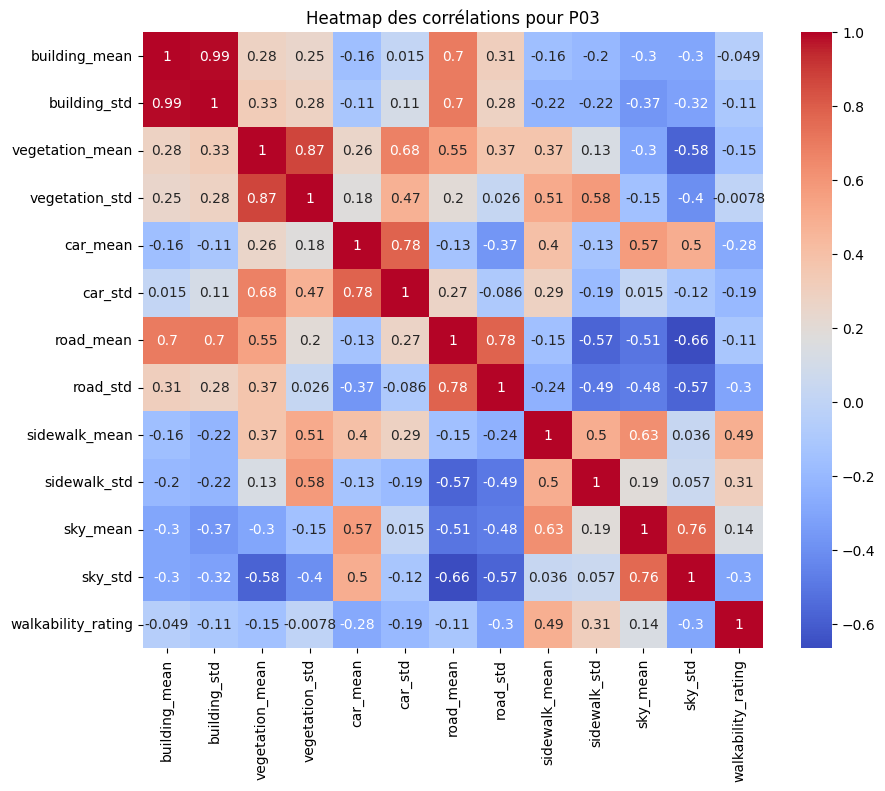

In [ ]:
# Sélection des colonnes features (moyennes et écart-types)
feature_cols = [c for c in df.columns if ("_mean" in c or "_std" in c)]

# Corrélation avec walkability_rating
corr_with_walk = df[feature_cols + ["walkability_rating"]].corr()["walkability_rating"].sort_values(ascending=False)

print("\nCorrélations avec walkability_rating ")
print(corr_with_walk)
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols + ["walkability_rating"]].corr(), annot=True, cmap="coolwarm")
plt.title(f"Heatmap des corrélations pour {participant_id}")
plt.show()


In [ ]:
participant_id = "P04"
csv_file = f"{participant_id}_viewport_features.csv"

df = pd.read_csv(csv_file)
df

,participant_id,segment_id,walkability_rating,entropy,building_mean,building_std,vegetation_mean,vegetation_std,car_mean,car_std,road_mean,road_std,sidewalk_mean,sidewalk_std,sky_mean,sky_std
0,P04,1,2.0,0.217236,2.501992e-04,0.007042,0.003894,0.006436,0.045049,0.037837,4.688856e-06,0.000088,0.001996,0.004769,0.008744,0.019377
1,P04,2,3.0,0.230148,1.068358e-04,0.002397,0.007537,0.005457,0.033347,0.033332,4.569543e-05,0.000480,0.003527,0.005820,0.013632,0.014886
2,P04,3,1.5,0.126144,4.676654e-07,0.000010,0.008593,0.008225,0.016020,0.026018,4.231428e-05,0.000346,0.001734,0.002478,0.001117,0.008949
3,P04,4,3.0,0.053001,0.000000e+00,0.000000,0.001389,0.001711,0.006613,0.005906,2.239798e-07,0.000004,0.000246,0.000967,0.001299,0.004544
4,P04,5,3.0,0.105630,2.808983e-06,0.000097,0.011758,0.008585,0.006185,0.008061,1.859774e-07,0.000006,0.000214,0.001059,0.003565,0.014309
5,P04,6,2.5,0.114888,1.142145e-06,0.000025,0.010435,0.010847,0.005782,0.012482,6.035288e-07,0.000023,0.002127,0.009173,0.004514,0.011972
6,P04,7,2.0,0.101841,1.118808e-05,0.000410,0.010194,0.009244,0.008626,0.018539,1.574244e-07,0.000006,0.000447,0.004650,0.001640,0.008283



Corrélations avec walkability_rating 
walkability_rating    1.000000
sky_mean              0.317473
sky_std              -0.001642
sidewalk_mean        -0.050519
vegetation_mean      -0.105688
road_std             -0.111732
sidewalk_std         -0.112672
building_mean        -0.143379
building_std         -0.185689
car_mean             -0.194216
road_mean            -0.195840
vegetation_std       -0.418200
car_std              -0.449268
Name: walkability_rating, dtype: float64


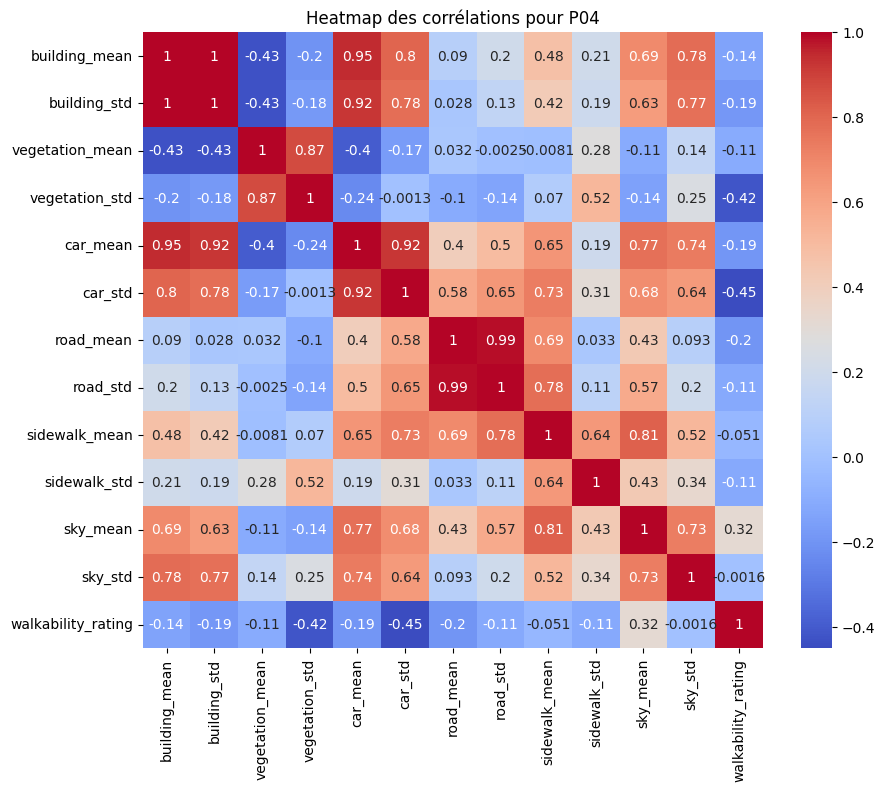

In [ ]:
# Sélection des colonnes features (moyennes et écart-types)
feature_cols = [c for c in df.columns if ("_mean" in c or "_std" in c)]

# Corrélation avec walkability_rating
corr_with_walk = df[feature_cols + ["walkability_rating"]].corr()["walkability_rating"].sort_values(ascending=False)

print("\nCorrélations avec walkability_rating ")
print(corr_with_walk)
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols + ["walkability_rating"]].corr(), annot=True, cmap="coolwarm")
plt.title(f"Heatmap des corrélations pour {participant_id}")
plt.show()

In [ ]:
from pathlib import Path
import pandas as pd

# Lister tous les fichiers du dossier actuel
files_in_colab = list(Path(".").glob("*.csv"))
viewport_files = [f for f in files_in_colab if "viewport_features" in f.name]
print("Fichiers viewport à analyser :", viewport_files)



Fichiers viewport à analyser : [PosixPath('P05_viewport_features.csv'), PosixPath('P03_viewport_features.csv'), PosixPath('P01_viewport_features.csv'), PosixPath('P07_viewport_features.csv'), PosixPath('P06_viewport_features.csv'), PosixPath('P04_viewport_features.csv'), PosixPath('P09_viewport_features.csv'), PosixPath('P08_viewport_features.csv'), PosixPath('P02_viewport_features.csv')]


In [ ]:
all_dfs = []

for fpath in viewport_files:
    df = pd.read_csv(fpath)
    # Extraire l'ID participant depuis le nom du fichier
    pid = fpath.stem.split("_")[0]  # ex: P01_viewport_features.csv → P01
    df["participant_id"] = pid
    all_dfs.append(df)

# Fusion globale
df_all = pd.concat(all_dfs, ignore_index=True)
print(f"Nombre total de segments multi-participants : {len(df_all)}")
df_all.head()


Nombre total de segments multi-participants : 63


,participant_id,segment_id,walkability_rating,entropy,building_mean,building_std,vegetation_mean,vegetation_std,car_mean,car_std,road_mean,road_std,sidewalk_mean,sidewalk_std,sky_mean,sky_std
0,P05,1,1.5,0.144064,0.000010,0.000278,0.002127,0.005639,0.024768,0.020894,0.000006,0.000139,0.000607,0.002008,0.006990,0.024020
1,P05,2,4.0,0.156761,0.000017,0.000110,0.005719,0.005865,0.019164,0.029044,0.000001,0.000028,0.001700,0.003083,0.008465,0.008171
2,P05,3,3.0,0.121260,0.000047,0.000381,0.006852,0.005259,0.017188,0.026876,0.000018,0.000137,0.001585,0.002034,0.000915,0.001858
3,P05,4,4.0,0.097093,0.000167,0.001189,0.007579,0.008002,0.006168,0.013912,0.000008,0.000182,0.001347,0.009573,0.003174,0.007952
4,P05,5,4.0,0.092160,0.000013,0.000228,0.009413,0.007162,0.006219,0.015090,0.000000,0.000000,0.000351,0.001245,0.002249,0.007519


In [ ]:
feature_cols = [c for c in df_all.columns if "_mean" in c or "_std" in c]

# Stats globales
print("--- Statistiques descriptives globales ---")
print(df_all[feature_cols + ["walkability_rating"]].describe())

# Stats par participant
print("--- Stats par participant ---")
stats_by_participant = df_all.groupby("participant_id")[feature_cols + ["walkability_rating"]].describe()
print(stats_by_participant)


--- Statistiques descriptives globales ---
       building_mean  building_std  vegetation_mean  vegetation_std  \
count   6.300000e+01     63.000000        63.000000       63.000000   
mean    3.317196e-05      0.000677         0.007263        0.006436   
std     7.185242e-05      0.001768         0.003606        0.002711   
min     0.000000e+00      0.000000         0.000771        0.001055   
25%     5.244464e-07      0.000011         0.004054        0.005175   
50%     5.480105e-06      0.000097         0.008078        0.006436   
75%     2.089086e-05      0.000348         0.010020        0.008465   
max     3.650141e-04      0.010486         0.013759        0.011767   

        car_mean    car_std  road_mean   road_std  sidewalk_mean  \
count  63.000000  63.000000  63.000000  63.000000      63.000000   
mean    0.013579   0.017846   0.000022   0.000243       0.001329   
std     0.010964   0.011219   0.000037   0.000334       0.001321   
min     0.001357   0.002821   0.000000   0.00

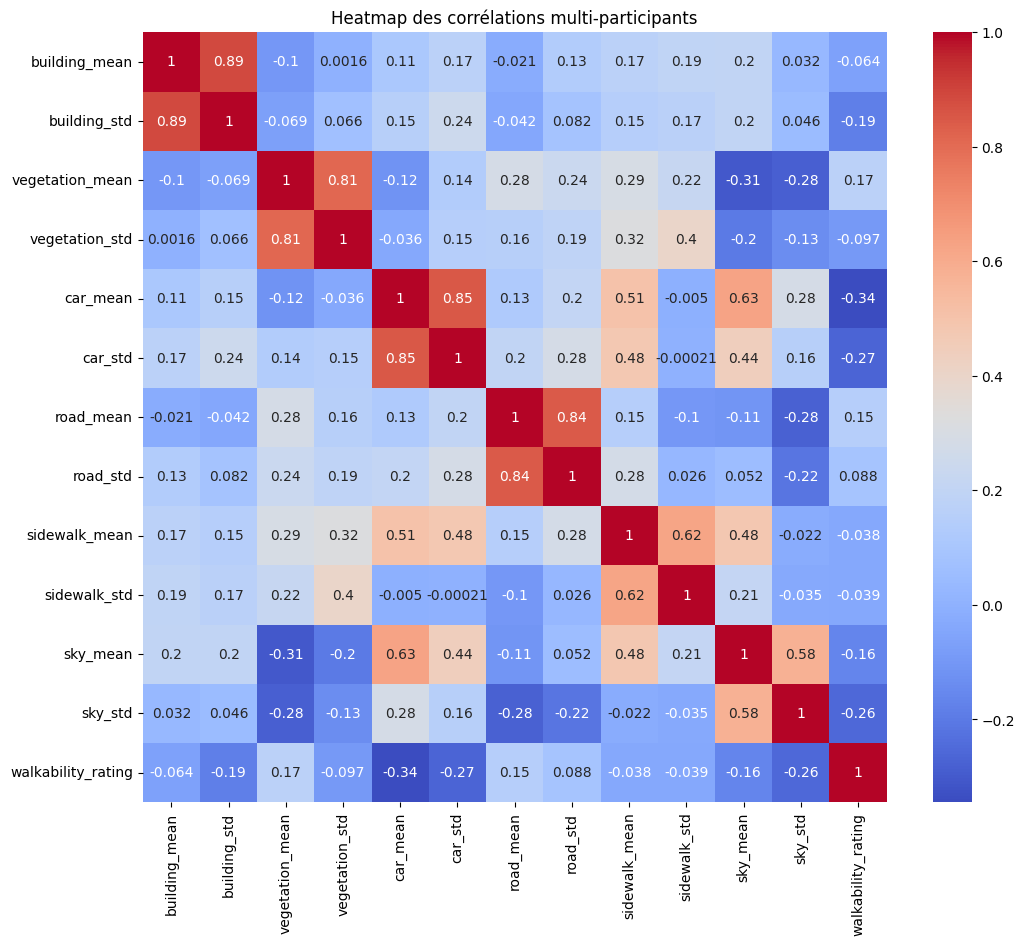

--- Corrélations avec walkability_rating ---
vegetation_mean    0.172290
road_mean          0.149605
road_std           0.088413
sidewalk_mean     -0.038018
sidewalk_std      -0.038721
building_mean     -0.063951
vegetation_std    -0.096605
sky_mean          -0.164701
building_std      -0.185012
sky_std           -0.258013
car_std           -0.266479
car_mean          -0.344611
Name: walkability_rating, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_all[feature_cols + ["walkability_rating"]].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Heatmap des corrélations multi-participants")
plt.show()

# Corrélations triées avec walkability_rating
corr_with_walk = corr_matrix["walkability_rating"].drop("walkability_rating").sort_values(ascending=False)
print("--- Corrélations avec walkability_rating ---")
print(corr_with_walk)


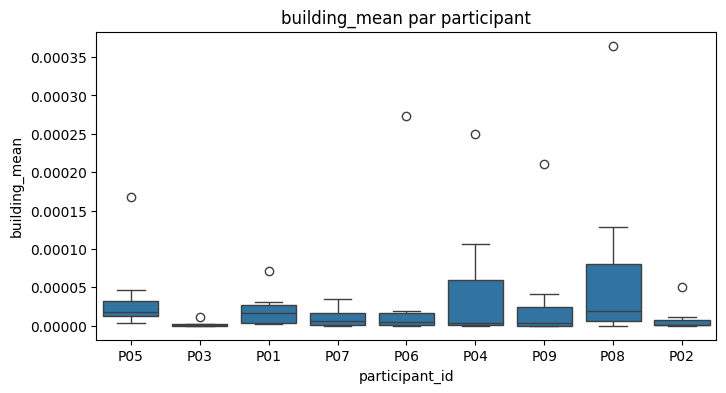

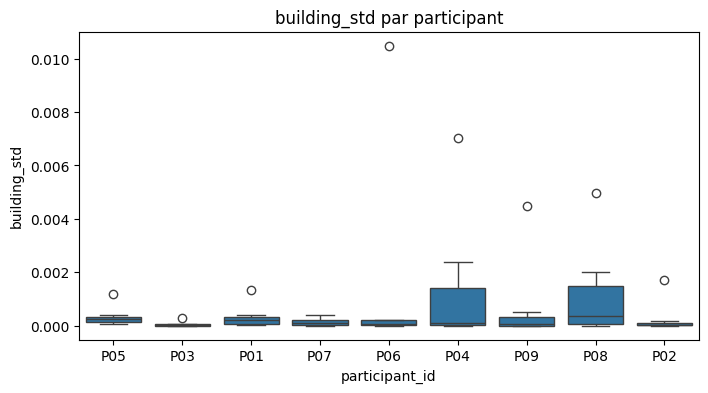

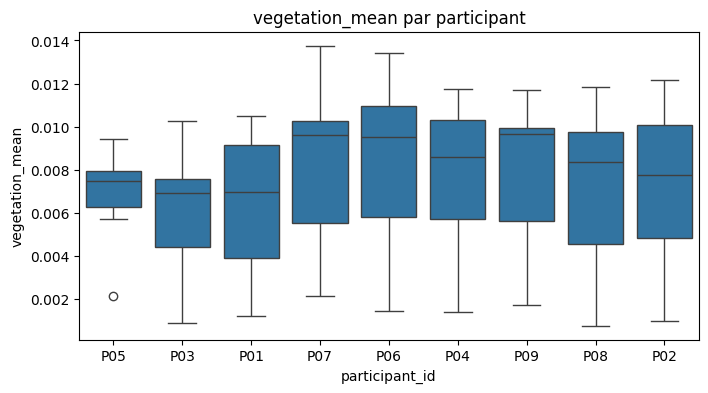

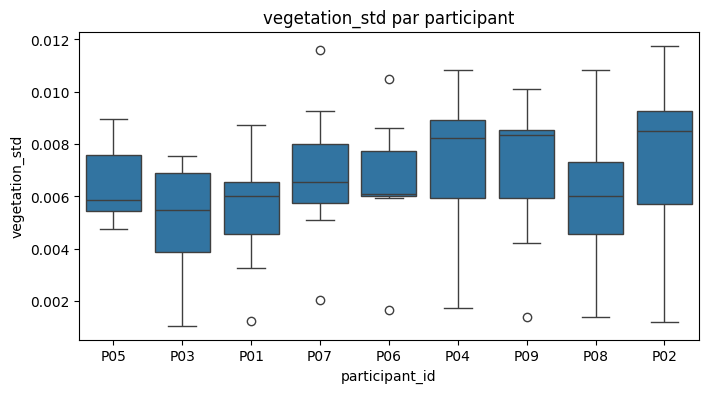

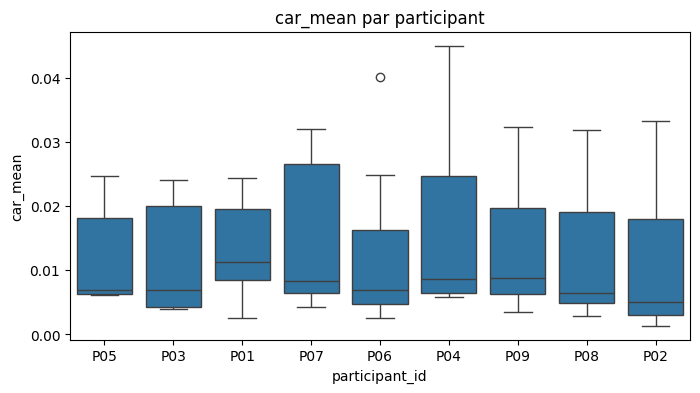

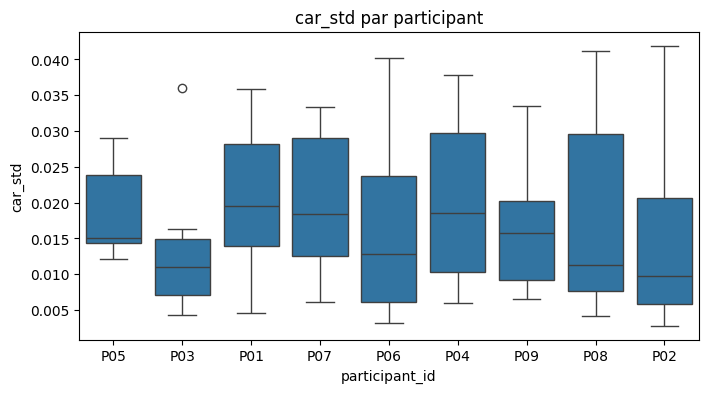

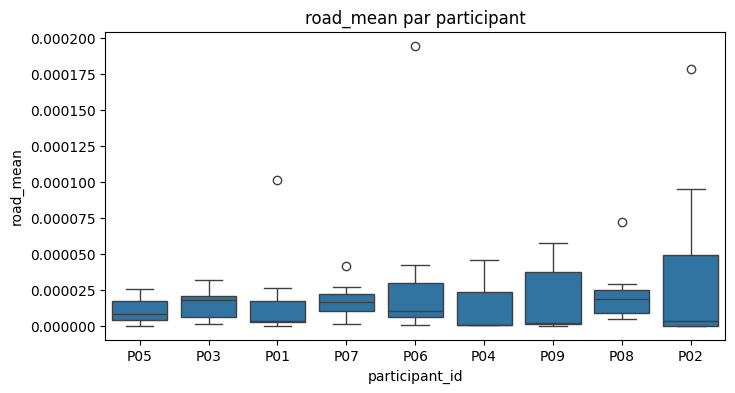

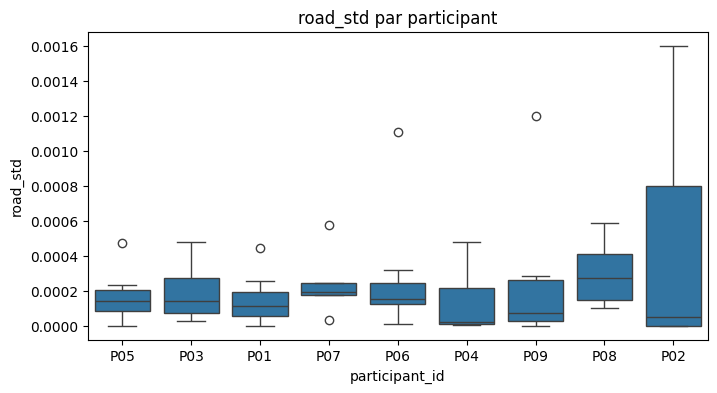

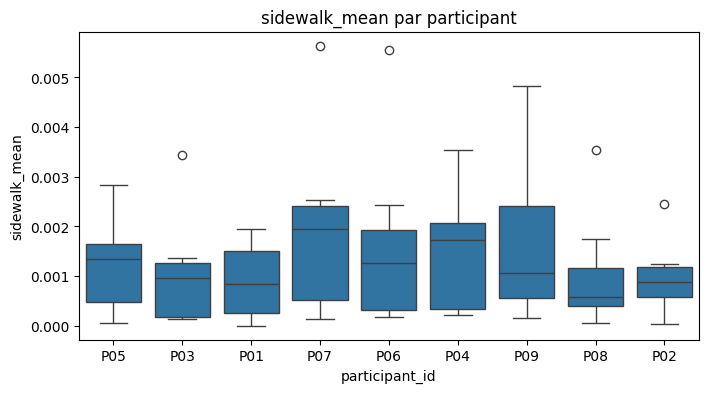

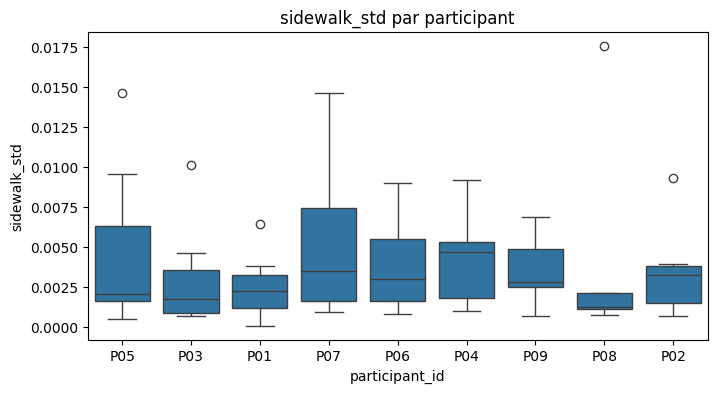

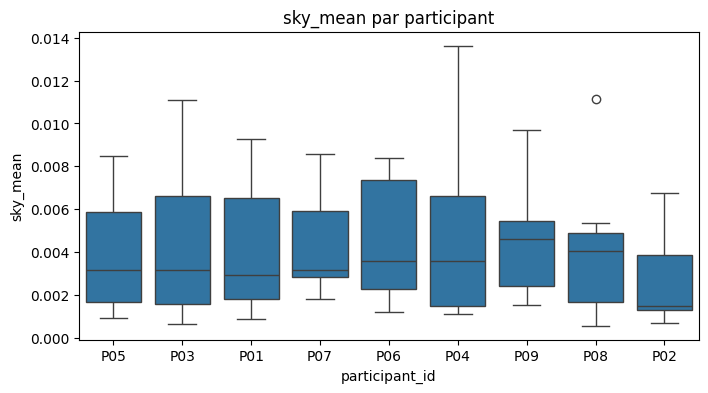

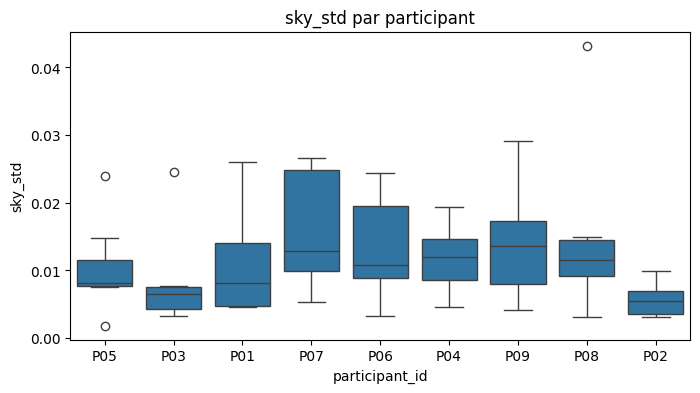

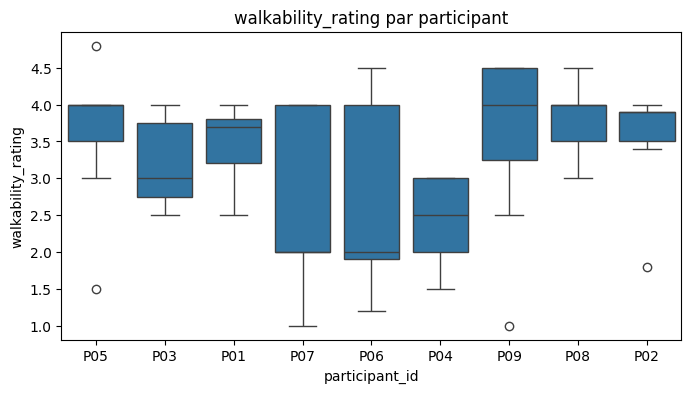

In [ ]:
for feature in feature_cols + ["walkability_rating"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_all, x="participant_id", y=feature)
    plt.title(f"{feature} par participant")
    plt.show()


In [ ]:
feature_cols = [c for c in df_all.columns if "_mean" in c or "_std" in c]

# Stats globales par segment (tous participants confondus)
stats_by_segment = df_all.groupby("segment_id")[feature_cols + ["walkability_rating"]].describe()
print(stats_by_segment)


           building_mean                                                  \
                   count      mean       std           min           25%   
segment_id                                                                 
1                    9.0  0.000033  0.000082  2.512182e-08  3.265113e-07   
2                    9.0  0.000044  0.000070  2.217463e-06  9.370297e-06   
3                    9.0  0.000017  0.000026  7.689236e-08  5.812274e-07   
4                    9.0  0.000059  0.000127  0.000000e+00  0.000000e+00   
5                    9.0  0.000005  0.000006  0.000000e+00  2.532397e-07   
6                    9.0  0.000051  0.000093  3.477787e-08  1.329231e-06   
7                    9.0  0.000023  0.000019  0.000000e+00  3.716697e-06   

                                         building_std            ...  \
                 50%       75%       max        count      mean  ...   
segment_id                                                       ...   
1           0.000005  0

In [ ]:
for seg_id, group in df_all.groupby("segment_id"):
    corr = group[feature_cols + ["walkability_rating"]].corr()
    print(f"--- Segment {seg_id} ---")
    print(corr["walkability_rating"].drop("walkability_rating"))


--- Segment 1 ---
building_mean      0.020812
building_std       0.058571
vegetation_mean   -0.421833
vegetation_std    -0.640083
car_mean          -0.344187
car_std           -0.039486
road_mean          0.052417
road_std          -0.046320
sidewalk_mean     -0.110401
sidewalk_std      -0.144528
sky_mean           0.597877
sky_std            0.444869
Name: walkability_rating, dtype: float64
--- Segment 2 ---
building_mean     -0.850449
building_std      -0.846234
vegetation_mean    0.132055
vegetation_std    -0.406976
car_mean           0.050805
car_std            0.047942
road_mean          0.132616
road_std          -0.254713
sidewalk_mean     -0.284834
sidewalk_std      -0.324718
sky_mean          -0.700023
sky_std           -0.574938
Name: walkability_rating, dtype: float64
--- Segment 3 ---
building_mean      0.108353
building_std       0.131408
vegetation_mean   -0.142388
vegetation_std    -0.234162
car_mean          -0.009652
car_std           -0.056761
road_mean          0.371

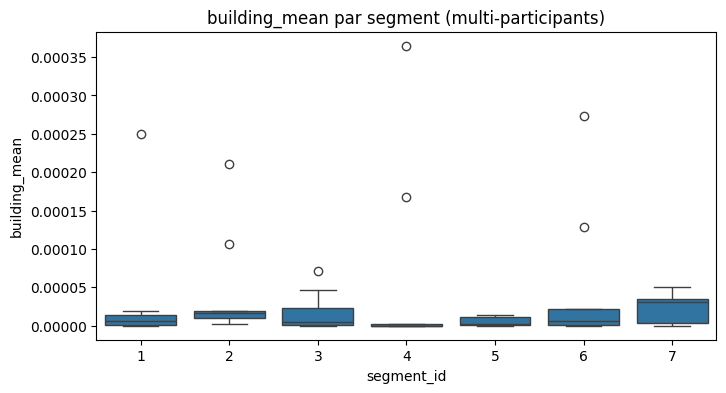

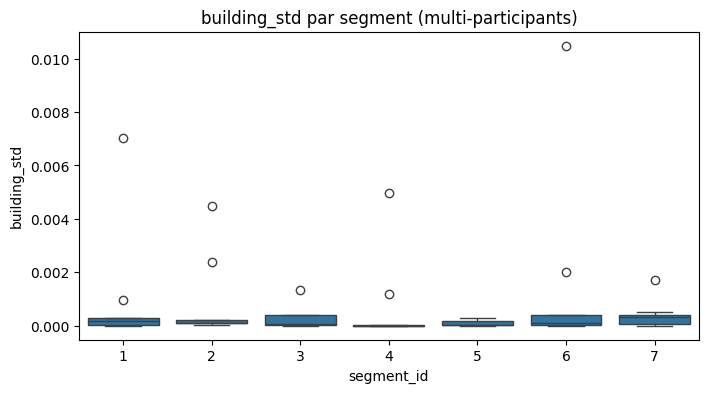

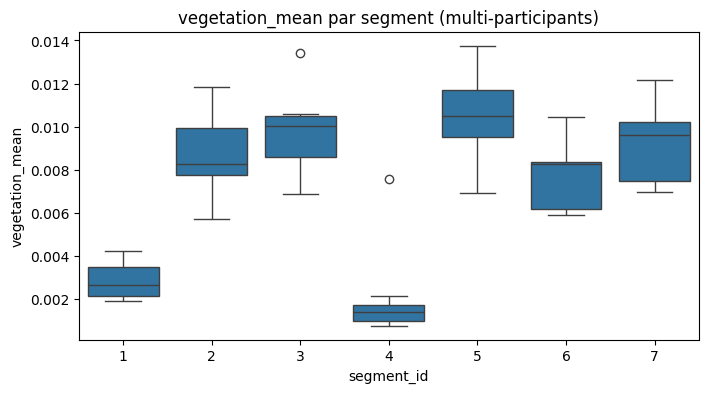

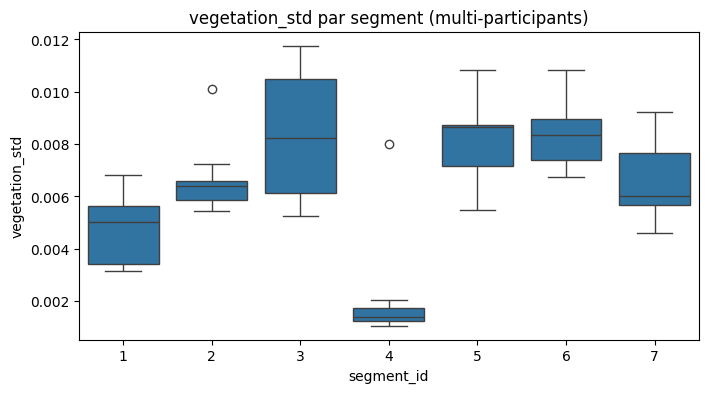

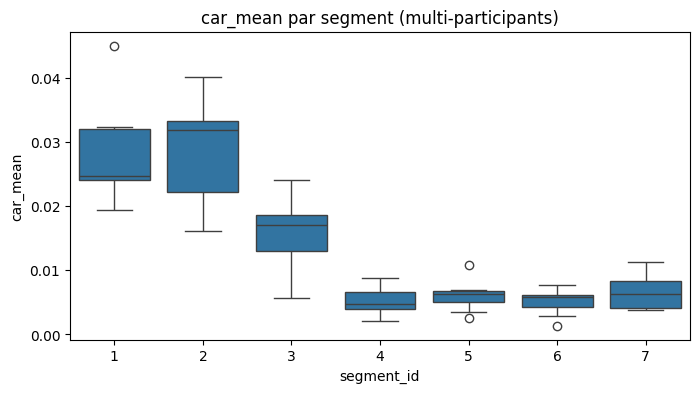

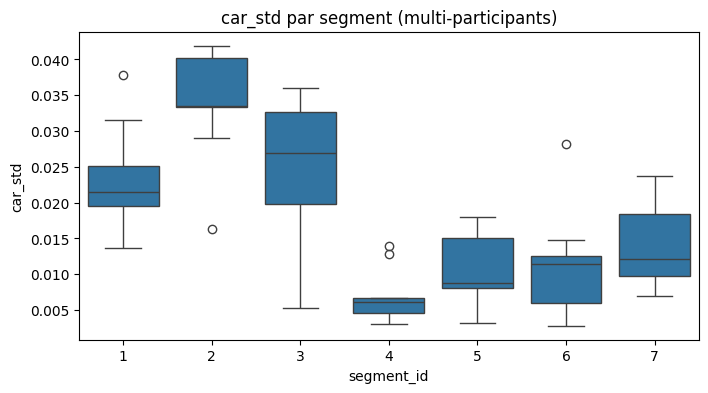

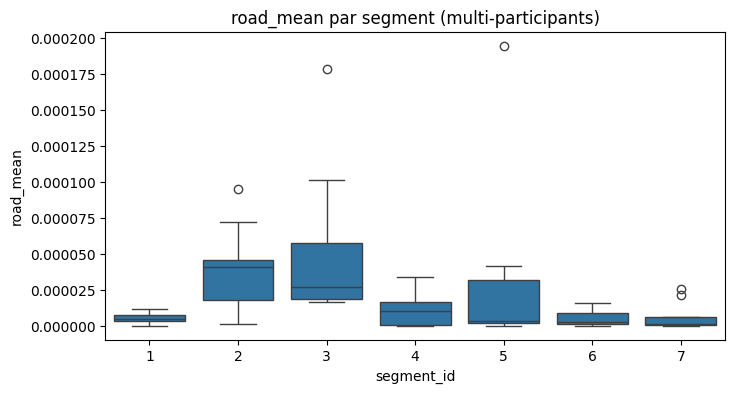

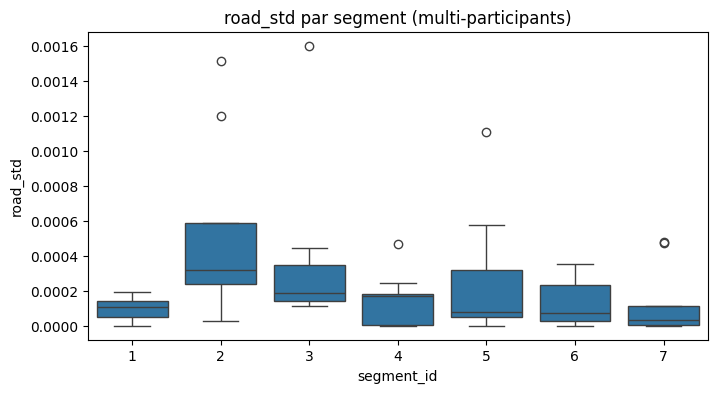

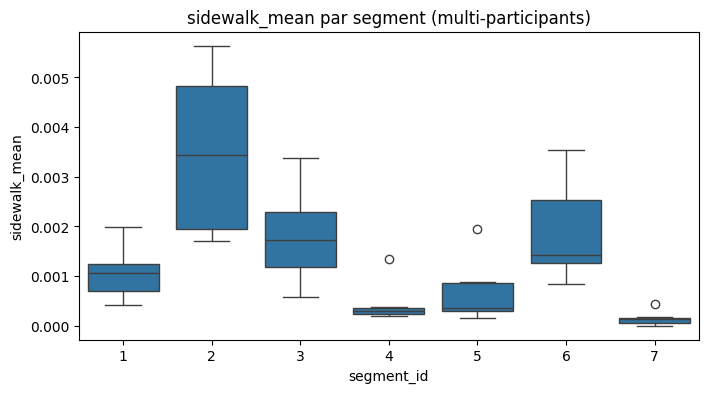

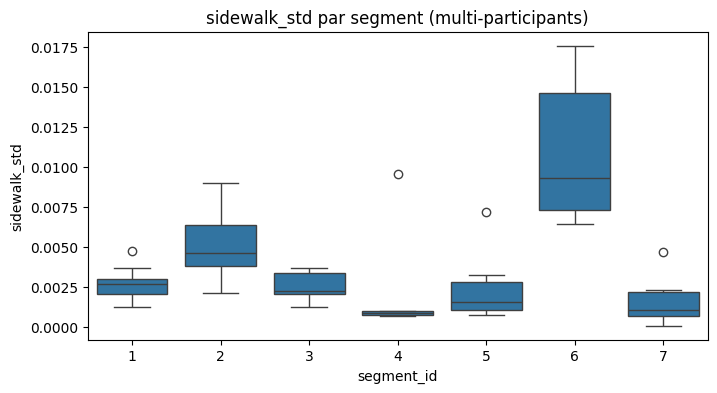

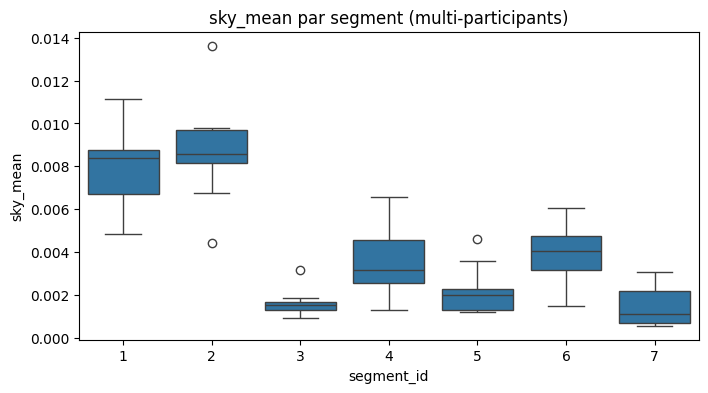

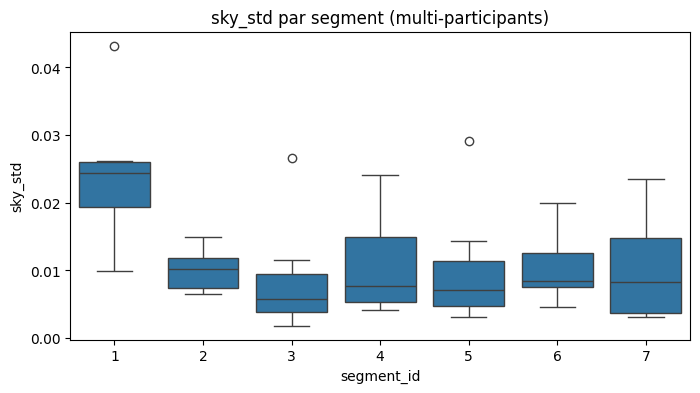

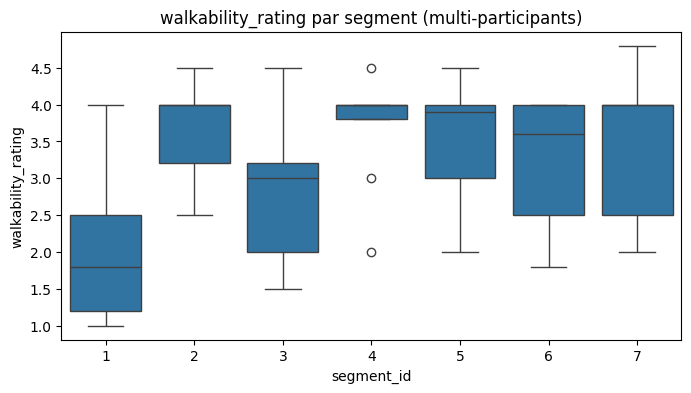

In [ ]:
for feature in feature_cols + ["walkability_rating"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_all, x="segment_id", y=feature)
    plt.title(f"{feature} par segment (multi-participants)")
    plt.show()


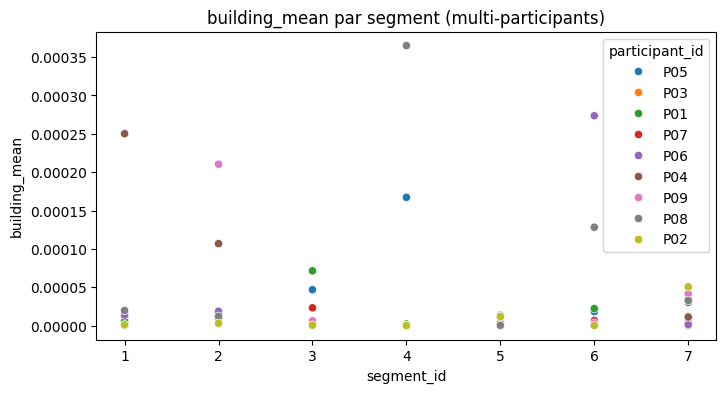

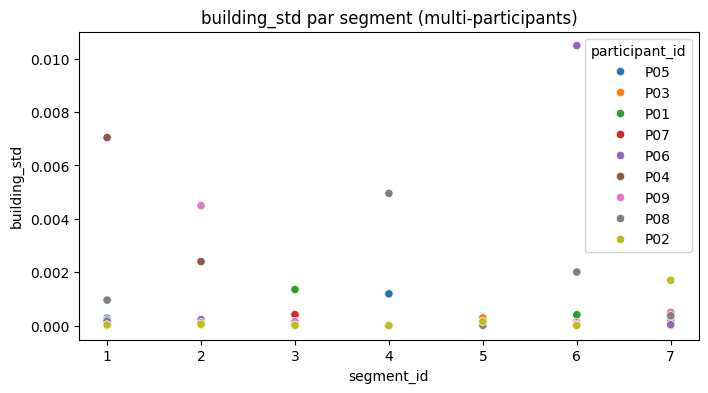

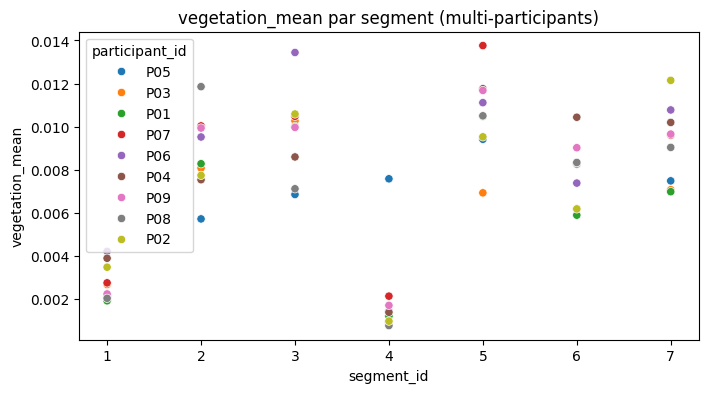

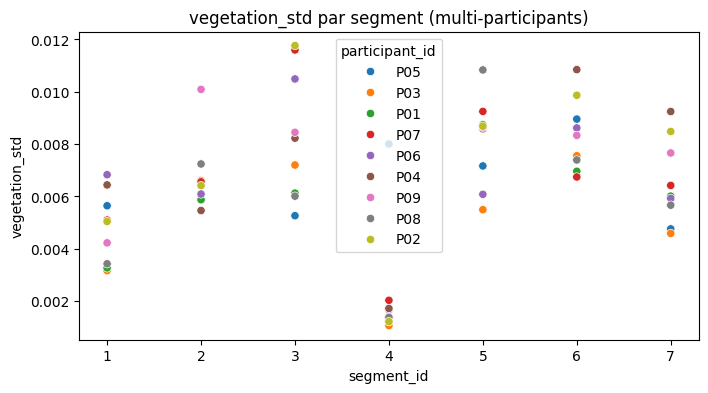

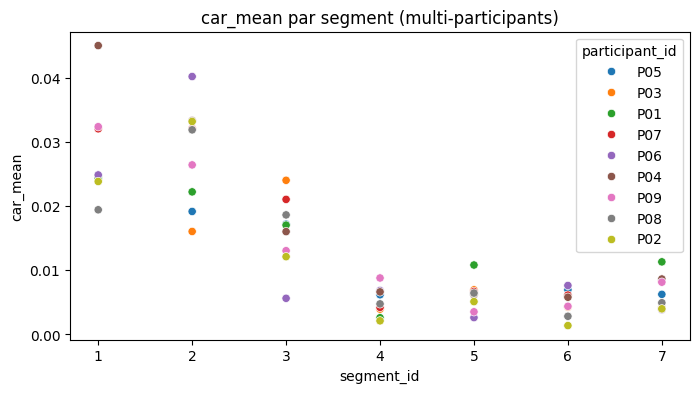

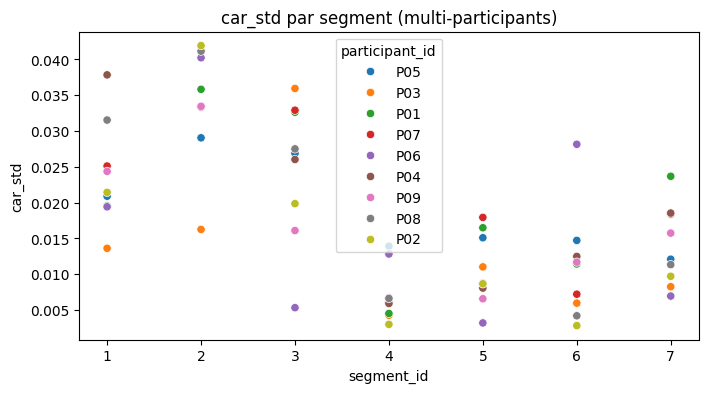

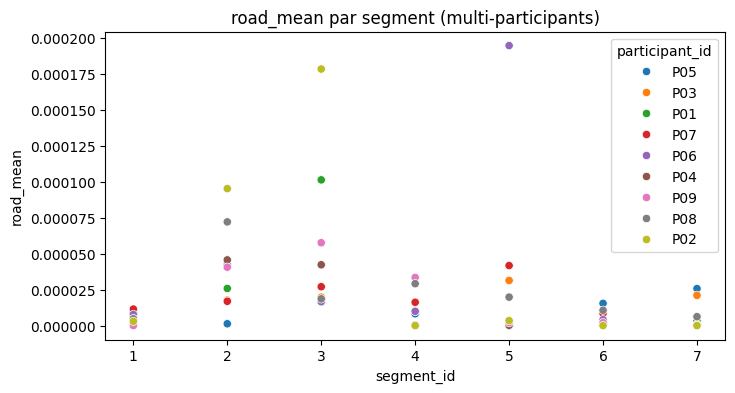

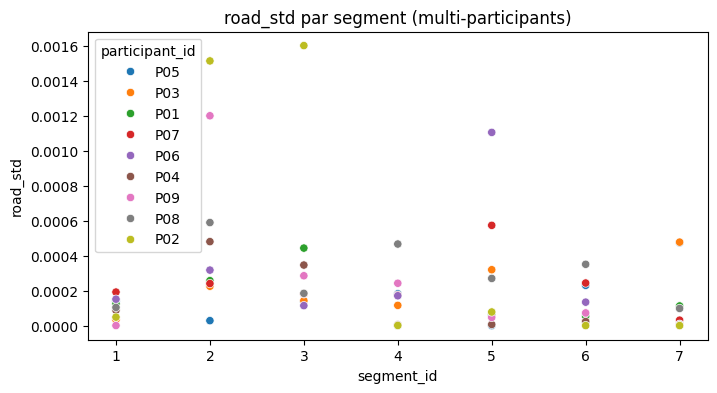

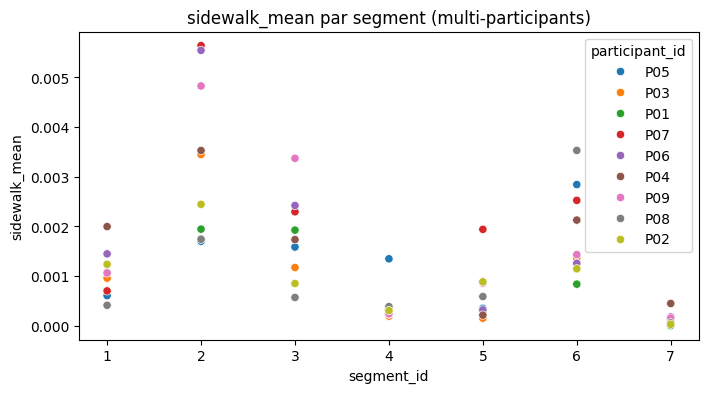

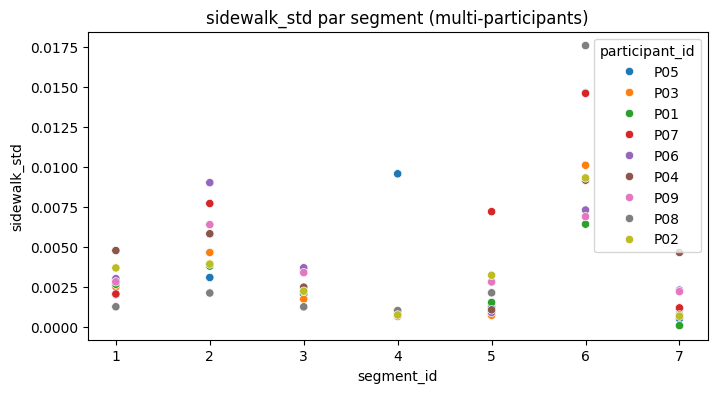

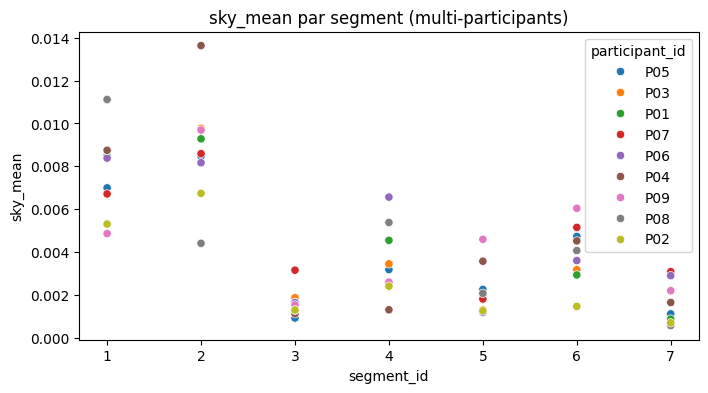

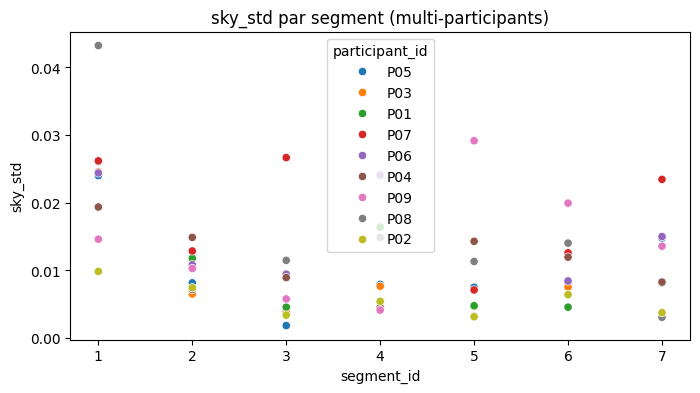

In [ ]:
for feature in feature_cols:
    plt.figure(figsize=(8,4))
    sns.scatterplot(data=df_all, x="segment_id", y=feature, hue="participant_id", palette="tab10")
    plt.title(f"{feature} par segment (multi-participants)")
    plt.show()
